# 06 — Feature Extraction and Analysis (Merged)

Unified notebook for feature extraction, EDA, feature ranking, and pruning for wheeled robot terrain classification using IMU + odometry.

## Project setup

- Runs: 4
- Classes: `dry_dirt_track`, `grass`, `muddy_dirt_track`, `smooth_terrain`, `cobbelstone`
- Windows: 2,346 (2s, 50% overlap, 100 Hz ≈ 200 samples/window)

All feature logic lives in `src/features.py`; this notebook only calls its public API.

---
**Depends on:** `04_cleaning`, `04b_filtering`, `05_windowing`  
**Feeds into:** `07_models.ipynb`

## Cell 1 — Imports and config

This cell centralizes all runtime flags, thresholds, and paths so the full pipeline can be toggled without editing downstream cells.

Thesis note: gy (yaw rate) is intentionally excluded from engineered features to reduce steering/turning confounds, even though this may remove a small amount of terrain-correlated signal in some scenarios.

In [11]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project root resolution
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    compute_window_features,
    get_feature_columns,
    get_eda_feature_columns,
    split_velocity_regime_datasets,
    apply_log_transform,
    compute_mutual_information,
    drop_high_correlation_features,
    run_feature_evaluation,
    print_feature_diagnostics,
    plot_pca_tsne,
    plot_feature_distributions,
    plot_correlation_heatmap,
)

# Unified config block
RUN_EDA = True
RUN_MERGED_LABEL_EDA = True
RUN_MI = True
RUN_PRUNING = True
RUN_PAIRWISE_PLOTS = True

SAMPLE_RATE = 100
VEL_COL = "net_speed"
MEAN_SPEED_THRESH = 0.6
SPEED_STD_THRESH = 0.10
CORR_THRESHOLD = 0.95
RANDOM_STATE = 42
TOP_N_HEATMAP = 25
TSNE_SAMPLE_CAP = 2500
DIRT_LABELS_TO_MERGE = {"dry_dirt_track", "muddy_dirt_track"}
MERGED_DIRT_LABEL = "dirt_track"

# Speed-invariant feature engineering flags
ENABLE_SPEED_NORMALIZED_FEATURES = True
EPS_SPEED = 0.05

ID_COLS = ["window_id", "run_id", "segment_id", "label", "t_start", "t_end", "n_samples"]

print("Config loaded.")
print(f"ENABLE_SPEED_NORMALIZED_FEATURES: {ENABLE_SPEED_NORMALIZED_FEATURES}")

Config loaded.
ENABLE_SPEED_NORMALIZED_FEATURES: True


## Cell 2 — Load data

This cell loads synchronized signals and window metadata, verifies key columns, and reports class balance before feature extraction.

In [12]:
# ── Input paths ──────────────────────────────────────────────────────────
filtered_path = PROJECT_ROOT / "data" / "interim" / "filtered" / "filtered_dataset.csv"
cleaned_path  = PROJECT_ROOT / "data" / "interim" / "cleaned" / "cleaned_dataset.csv"
windows_path  = PROJECT_ROOT / "data" / "processed" / "windowed_metadata.csv"

signal_path = filtered_path if filtered_path.exists() else cleaned_path

if not signal_path.exists():
    raise FileNotFoundError(
        f"No source signal dataset found. Expected one of:\n  {filtered_path}\n  {cleaned_path}"
    )
if not windows_path.exists():
    raise FileNotFoundError(f"Window metadata not found: {windows_path}\nRun 05_windowing.ipynb first.")

signals_df = (
    pd.read_csv(signal_path, low_memory=False)
    .sort_values(["run_id", "t_rel"])
    .reset_index(drop=True)
)
windows_df = pd.read_csv(windows_path, low_memory=False)

print(f"Signal source      : {signal_path}")
print(f"Signal shape       : {signals_df.shape}")
print(f"Windows shape      : {windows_df.shape}")
print(f"Velocity col       : {VEL_COL!r}  present={VEL_COL in signals_df.columns}")
print(f"\nSignal columns ({len(signals_df.columns)}):")
print(list(signals_df.columns))
print("\nLabel distribution in signals_df:")
print(signals_df["label"].value_counts(dropna=False).sort_index().to_string())

Signal source      : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/filtered/filtered_dataset.csv
Signal shape       : (298004, 14)
Windows shape      : (2346, 9)
Velocity col       : 'net_speed'  present=True

Signal columns (14):
['t', 't_rel', 'run_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2', 'label', 'net_speed', 'yaw_rate']

Label distribution in signals_df:
label
cobbelstone         56423
dry_dirt_track      79555
grass               66618
muddy_dirt_track    18972
smooth_terrain      76436


## Cell 3 — Feature extraction

This cell computes the full window-level feature table and saves it immediately so downstream analysis failures do not lose core extracted data.

In [13]:
features_df = compute_window_features(
    windows_df=windows_df,
    signals_df=signals_df,
    sample_rate=SAMPLE_RATE,
    vel_col=VEL_COL,
)

if ENABLE_SPEED_NORMALIZED_FEATURES:
    if "odom_mean_speed" in features_df.columns:
        speed_denom = features_df["odom_mean_speed"].astype(float).clip(lower=EPS_SPEED)
        if "acc_mag_energy" in features_df.columns:
            features_df["acc_mag_energy_over_speed"] = features_df["acc_mag_energy"].astype(float) / speed_denom
        if "gyro_mag_energy" in features_df.columns:
            features_df["gyro_mag_energy_over_speed"] = features_df["gyro_mag_energy"].astype(float) / speed_denom
        if "acc_mag_bandpower_5_20Hz" in features_df.columns:
            features_df["bandpower_5_20_over_speed"] = features_df["acc_mag_bandpower_5_20Hz"].astype(float) / speed_denom
        print("Added speed-normalized features: acc_mag_energy_over_speed, gyro_mag_energy_over_speed, bandpower_5_20_over_speed (when source columns exist)")
    else:
        print("[WARNING] odom_mean_speed missing; skipping speed-normalized feature engineering.")

feature_cols = get_feature_columns(features_df, id_cols=ID_COLS)

print(f"Features shape      : {features_df.shape}")
print(f"Feature count       : {len(feature_cols)}")
print("\nLabel distribution in features_df:")
print(features_df["label"].value_counts(dropna=False).sort_index().to_string())

num = features_df[feature_cols].replace([np.inf, -np.inf], np.nan)
nan_total = int(num.isna().sum().sum())
inf_total = int(np.isinf(features_df[feature_cols].to_numpy(dtype=float)).sum())
print(f"\nNaN count (features): {nan_total}")
print(f"Inf count (features): {inf_total}")

window_features_path = PROJECT_ROOT / "data" / "processed" / "window_features.csv"
window_features_path.parent.mkdir(parents=True, exist_ok=True)
features_df.to_csv(window_features_path, index=False)
print(f"Saved -> {window_features_path}")

Added speed-normalized features: acc_mag_energy_over_speed, gyro_mag_energy_over_speed, bandpower_5_20_over_speed (when source columns exist)
Features shape      : (2346, 196)
Feature count       : 189

Label distribution in features_df:
label
cobbelstone         355
dry_dirt_track      652
grass               488
muddy_dirt_track    145
smooth_terrain      706

NaN count (features): 0
Inf count (features): 0
Saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/window_features.csv


## Cell 4 — Dataset preparation

This cell prepares model-ready Dataset A and Dataset B, handles missing odometry gracefully, applies log transforms, and saves processed datasets before EDA.

In [14]:
out_dir = PROJECT_ROOT / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

HAS_ODOM = {"odom_mean_speed", "odom_speed_std"}.issubset(features_df.columns)
dataset_A = features_df.copy()
dataset_B = None

if HAS_ODOM:
    dataset_A, dataset_B = split_velocity_regime_datasets(
        features_df,
        vel_col="odom_mean_speed",
        mean_thresh=MEAN_SPEED_THRESH,
        std_thresh=SPEED_STD_THRESH,
        label_col="label",
        verbose=True,
    )
else:
    print("[WARNING] Missing odometry columns {'odom_mean_speed', 'odom_speed_std'}. Skipping Dataset B.")

dataset_A_tf = apply_log_transform(dataset_A)
dataset_B_tf = apply_log_transform(dataset_B) if dataset_B is not None else None

path_A = out_dir / "dataset_A_features.csv"
dataset_A_tf.to_csv(path_A, index=False)
print(f"Saved Dataset A -> {path_A} {dataset_A_tf.shape}")

path_B = out_dir / "dataset_B_features.csv"
if dataset_B_tf is not None:
    dataset_B_tf.to_csv(path_B, index=False)
    print(f"Saved Dataset B -> {path_B} {dataset_B_tf.shape}")
else:
    print("Skipped Dataset B save (no odometry split available).")

DATASET A — All windows
  Total windows : 2346
  Class distribution:
    cobbelstone                 355  ( 15.1%)  ████
    dry_dirt_track              652  ( 27.8%)  ████████
    grass                       488  ( 20.8%)  ██████
    muddy_dirt_track            145  (  6.2%)  █
    smooth_terrain              706  ( 30.1%)  █████████

DATASET B — Speed-controlled subset
  Criteria : odom_mean_speed < 0.6 m/s  AND  odom_speed_std < 0.1 m/s
  Windows kept    :  1635  (69.7%)
  Windows removed :   711  (30.3%)
  Class distribution:
    cobbelstone                 279  ( 17.1%)  █████
    dry_dirt_track              523  ( 32.0%)  █████████
    grass                       456  ( 27.9%)  ████████
    muddy_dirt_track             75  (  4.6%)  █
    smooth_terrain              302  ( 18.5%)  █████

  ⚠ WARNING:  'muddy_dirt_track' has only 75 windows in Dataset B.
[log1p transform] Applied to 8 columns.
[log1p transform] Applied to 8 columns.
Saved Dataset A -> /Users/pratyush/Desktop/DTU/B

## Cell 5 — EDA (guarded by RUN_EDA)

EDA is optional but useful for sanity-checking class separability and feature behavior before ranking and pruning.

FEATURE TABLE DIAGNOSTICS
  Shape          : (2346, 196)
  Feature count  : 103
  Missing values : 0 total

  Label distribution (label):
                  count  pct_%
label                         
cobbelstone         355  15.13
dry_dirt_track      652  27.79
grass               488  20.80
muddy_dirt_track    145   6.18
smooth_terrain      706  30.09

  Per-class mean of key features:
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  ay_jerk_rms  gz_jerk_rms  cross_ay_gx  cross_ay_gz
label                                                                                                                                     
cobbelstone            0.2590       0.1135          2.5418        6.9629        3.0285       9.7973     205.2919      -0.0552       0.0402
dry_dirt_track         0.1544       0.0685          1.6014        5.2787        2.0374       5.5154     123.9640      -0.0557       0.0198
grass                  0.1374       0.0588          1.

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


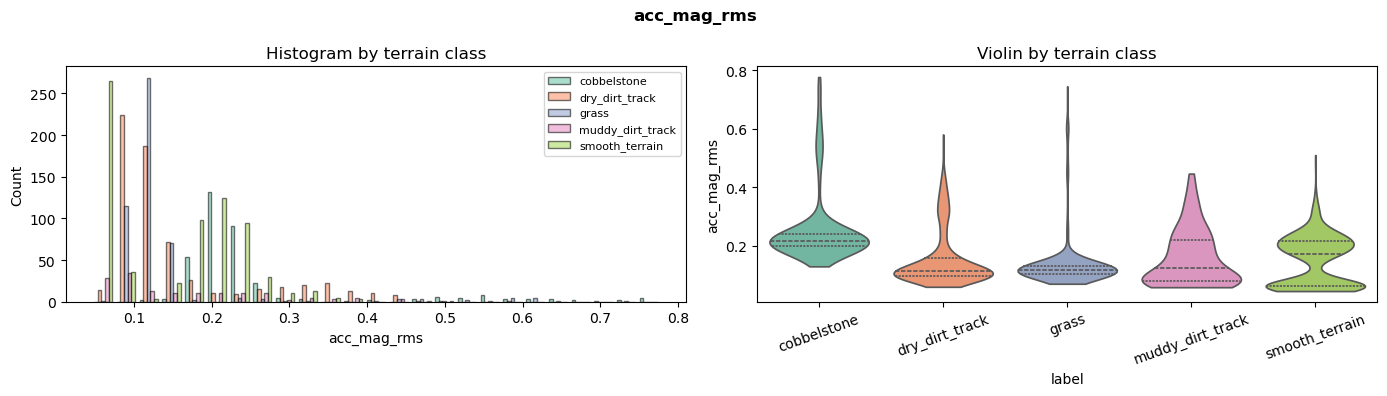

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


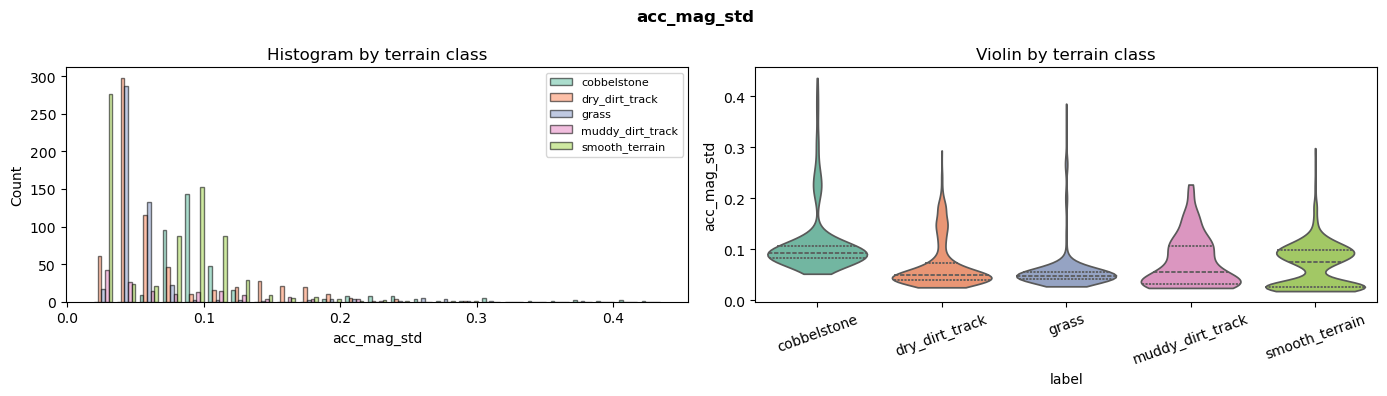

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


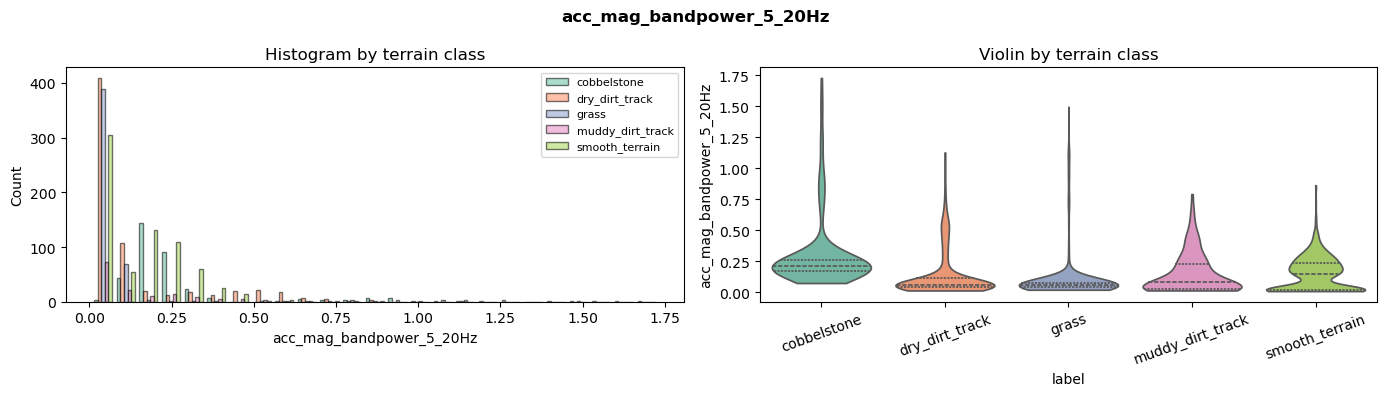

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


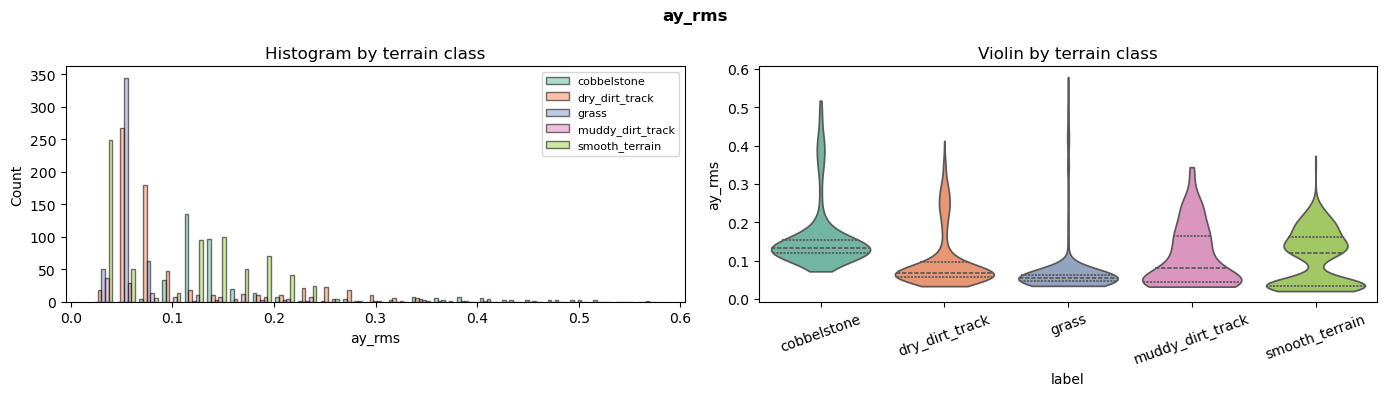

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


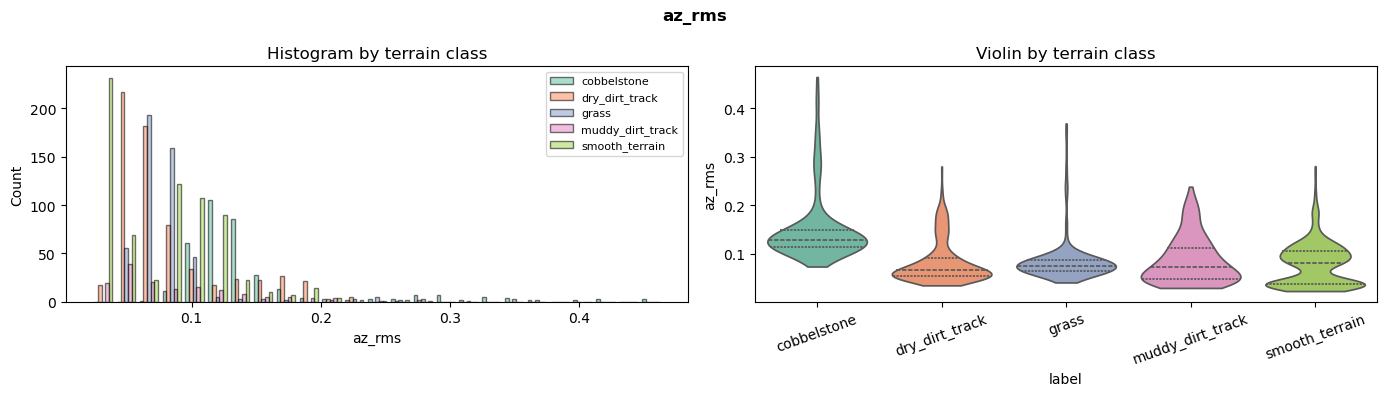

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


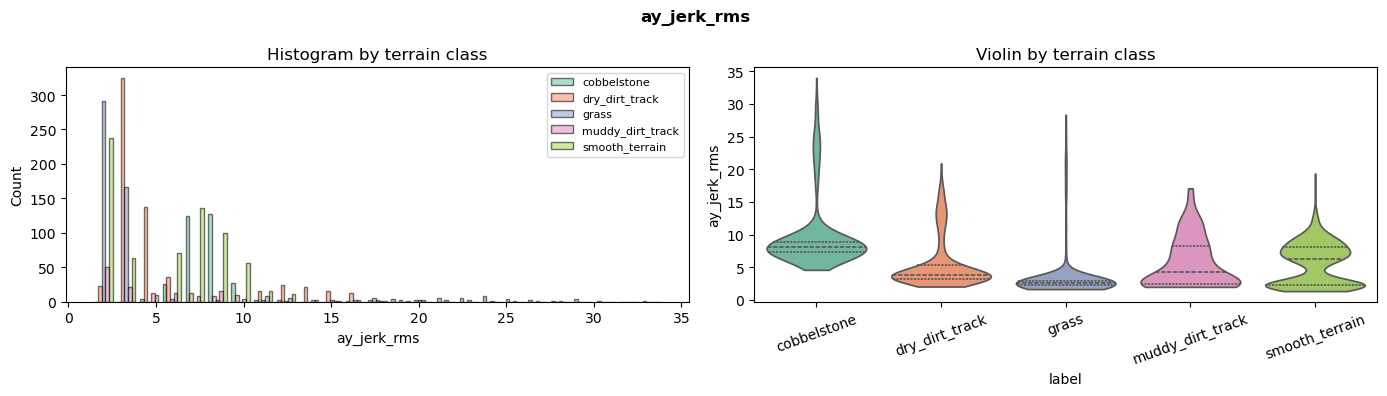

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


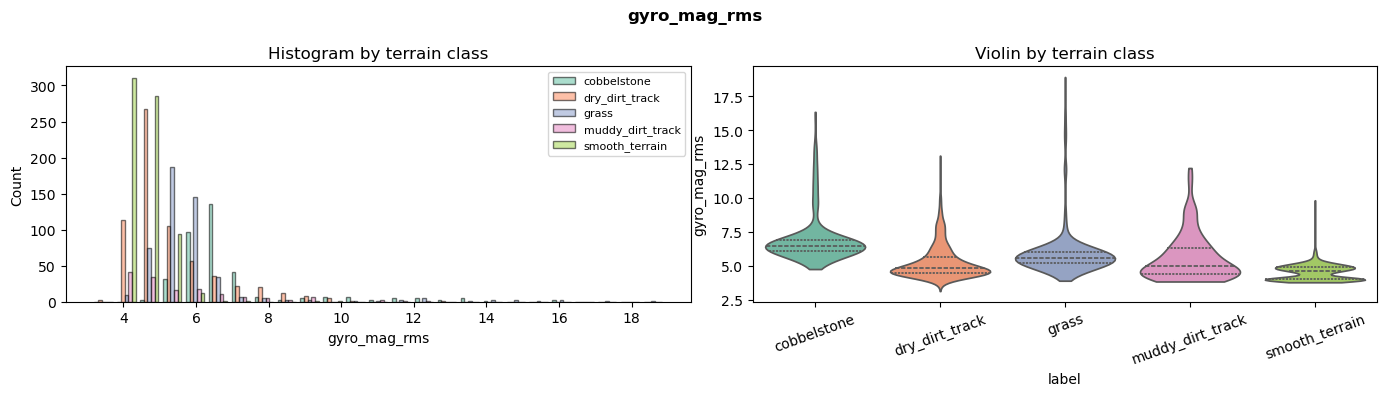

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


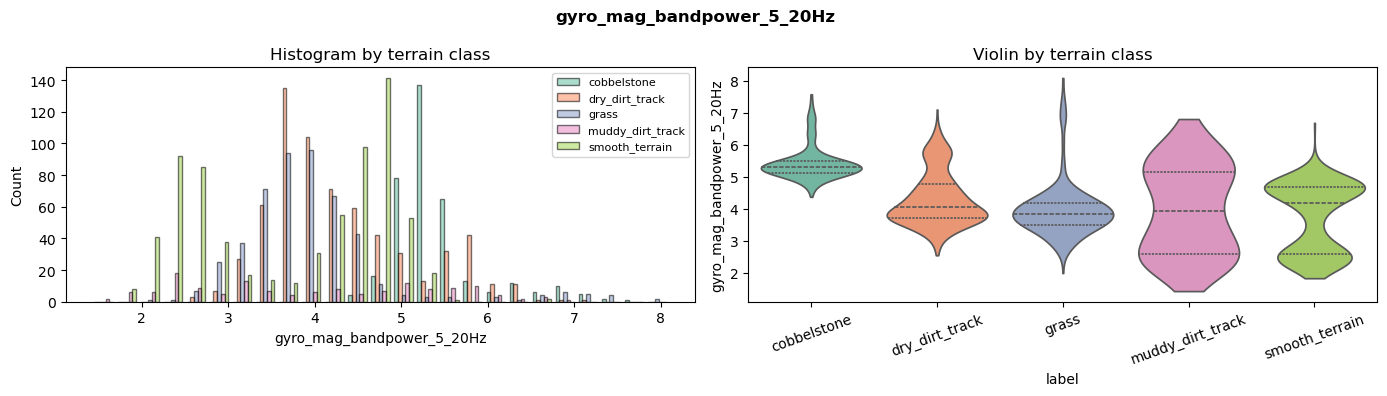

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


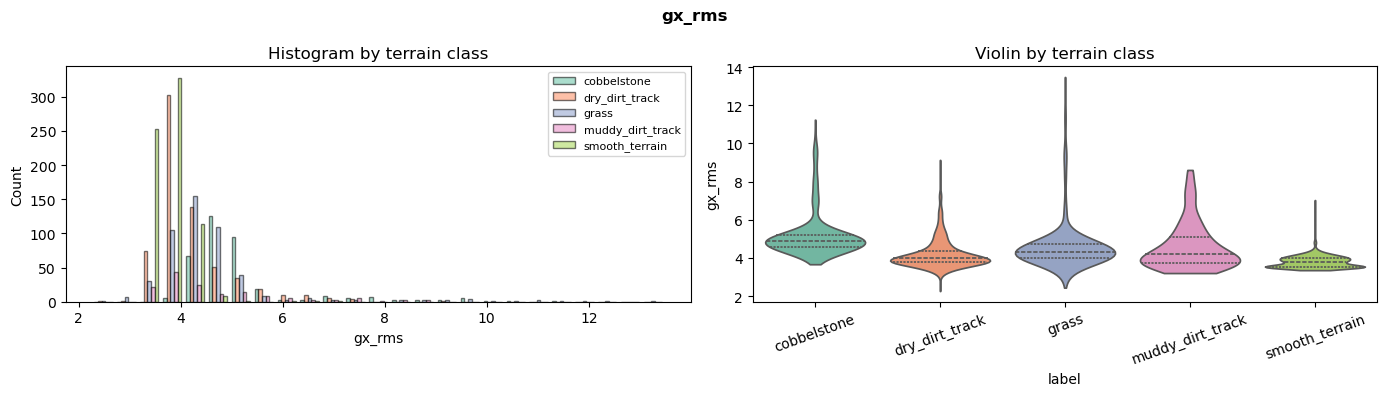

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


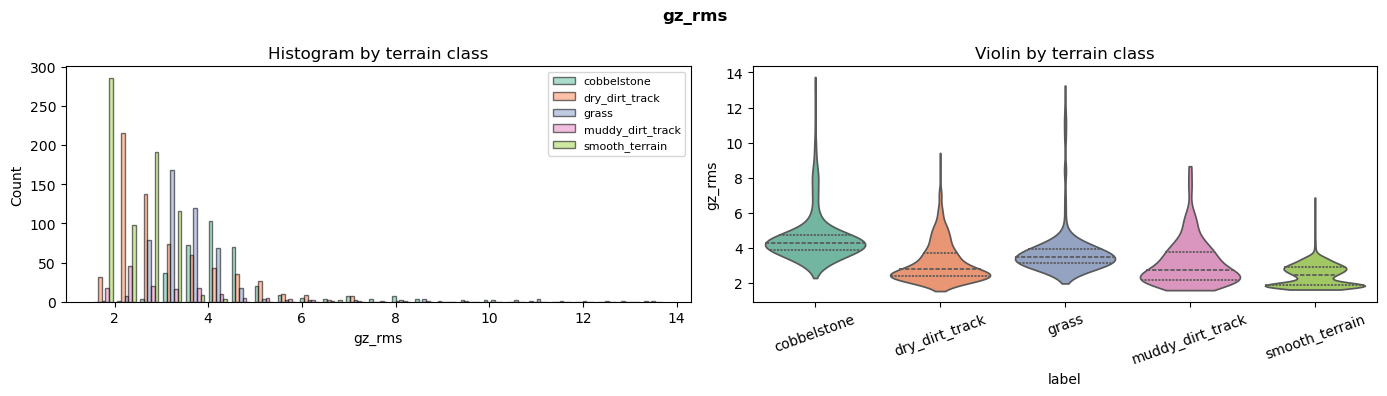

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


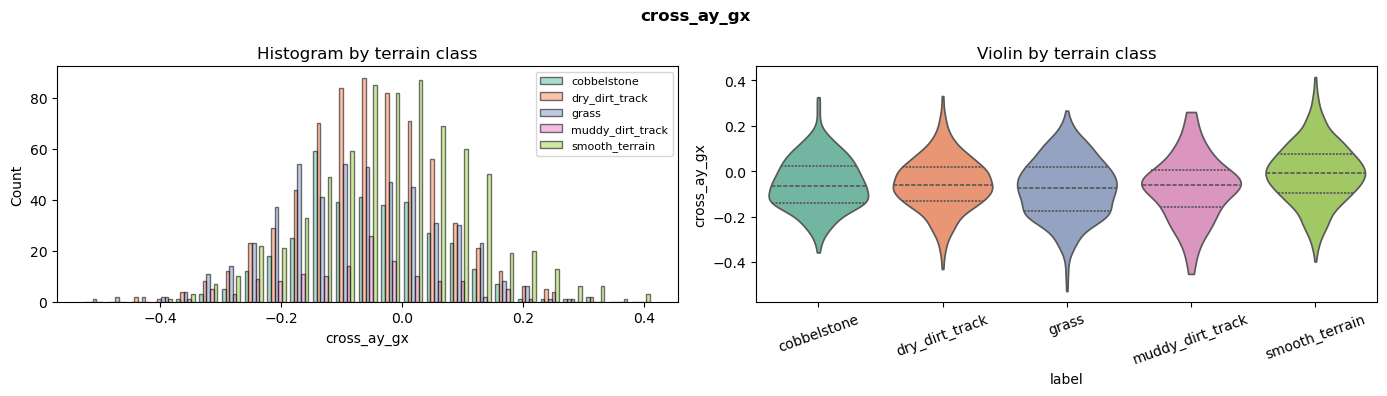

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


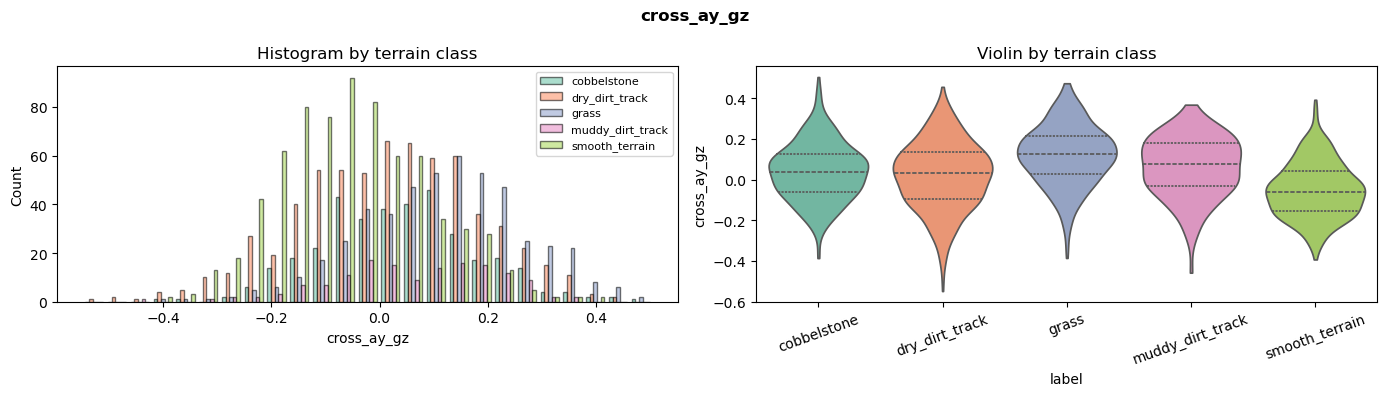

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


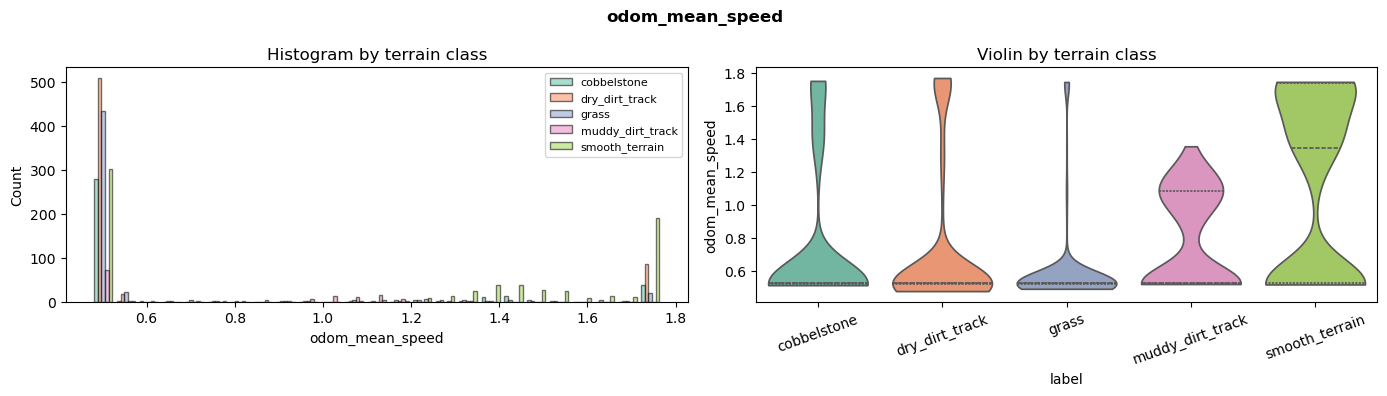

[plot_feature_distributions] Saved 13 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A


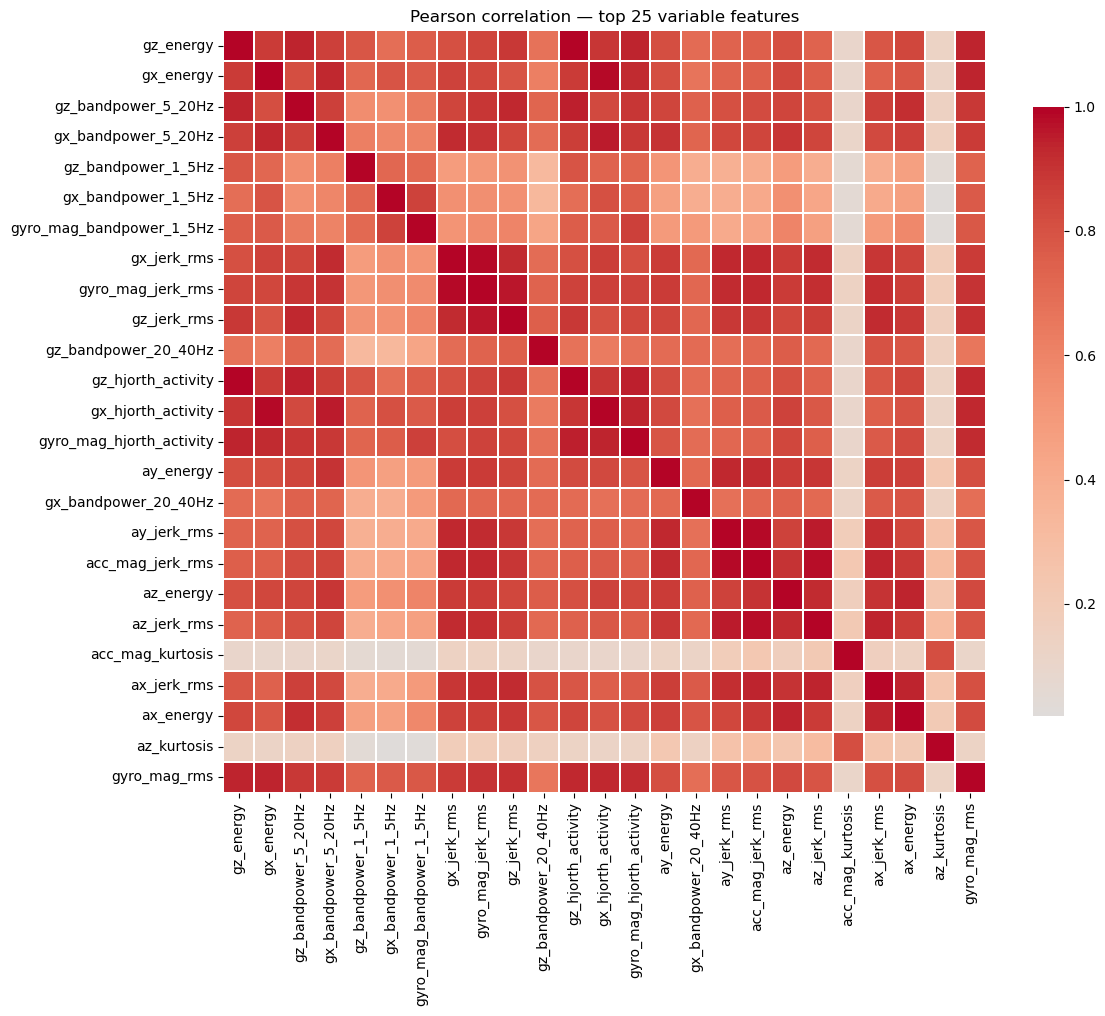


Top 15 absolute correlation pairs:
          feature_1                feature_2     corr
          gz_energy       gz_hjorth_activity 0.995303
        ay_jerk_rms         acc_mag_jerk_rms 0.984733
        gx_jerk_rms        gyro_mag_jerk_rms 0.982532
          gx_energy       gx_hjorth_activity 0.982373
   acc_mag_jerk_rms              az_jerk_rms 0.977023
  gyro_mag_jerk_rms              gz_jerk_rms 0.961321
        ay_jerk_rms              az_jerk_rms 0.955200
gx_bandpower_5_20Hz       gx_hjorth_activity 0.950570
gz_bandpower_5_20Hz       gz_hjorth_activity 0.946513
 gz_hjorth_activity gyro_mag_hjorth_activity 0.943814
   acc_mag_jerk_rms              ax_jerk_rms 0.941782
          gz_energy gyro_mag_hjorth_activity 0.941172
          gz_energy      gz_bandpower_5_20Hz 0.940717
          az_energy                ax_energy 0.938025
          gz_energy             gyro_mag_rms 0.937292


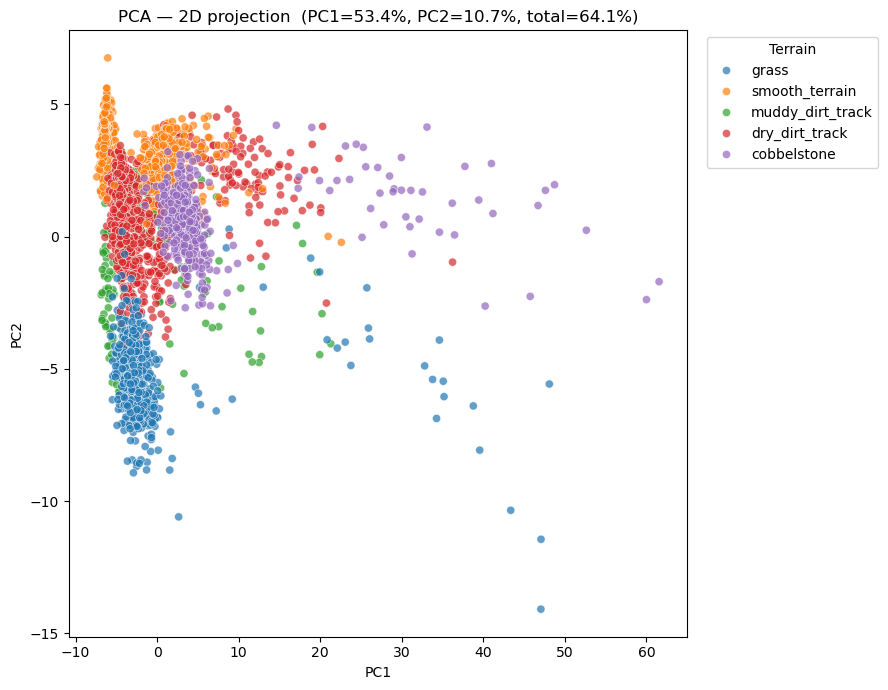

PCA explained variance: PC1=0.534, PC2=0.107, total=0.641


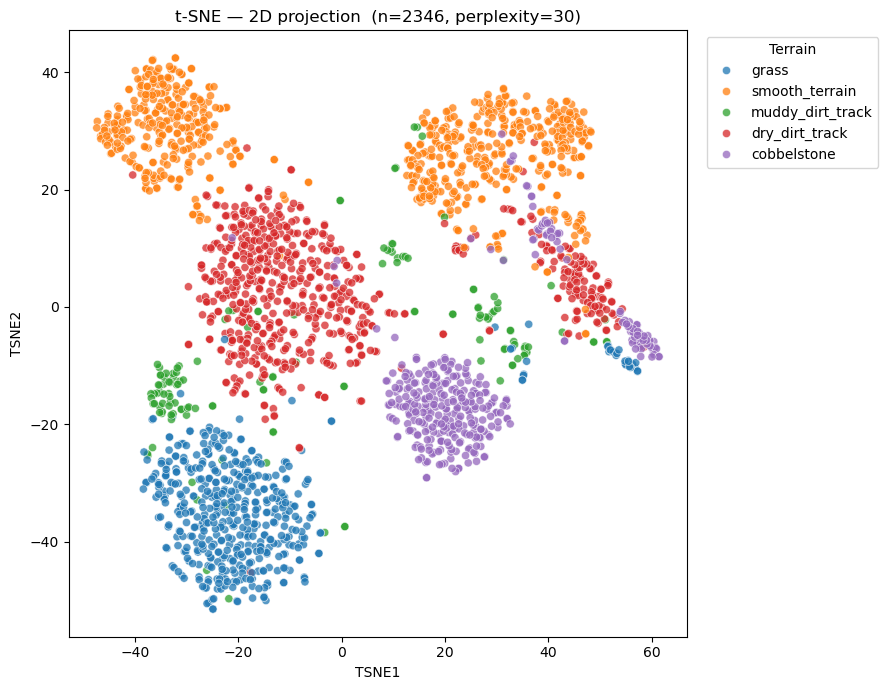

Dataset A EDA saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A
FEATURE TABLE DIAGNOSTICS
  Shape          : (1635, 196)
  Feature count  : 103
  Missing values : 0 total

  Label distribution (label):
                  count  pct_%
label                         
cobbelstone         279  17.06
dry_dirt_track      523  31.99
grass               456  27.89
muddy_dirt_track     75   4.59
smooth_terrain      302  18.47

  Per-class mean of key features:
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  ay_jerk_rms  gz_jerk_rms  cross_ay_gx  cross_ay_gz
label                                                                                                                                     
cobbelstone            0.2114       0.0897          2.2858        6.4579        2.7289       7.7350     180.1687      -0.0776       0.0713
dry_dirt_track         0.1125       0.0480          1.2453    

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


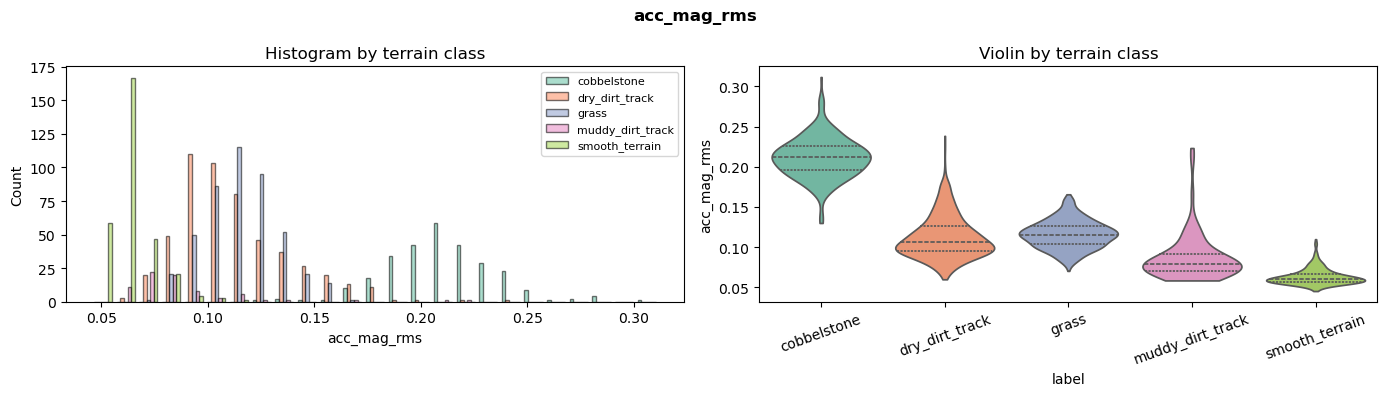

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


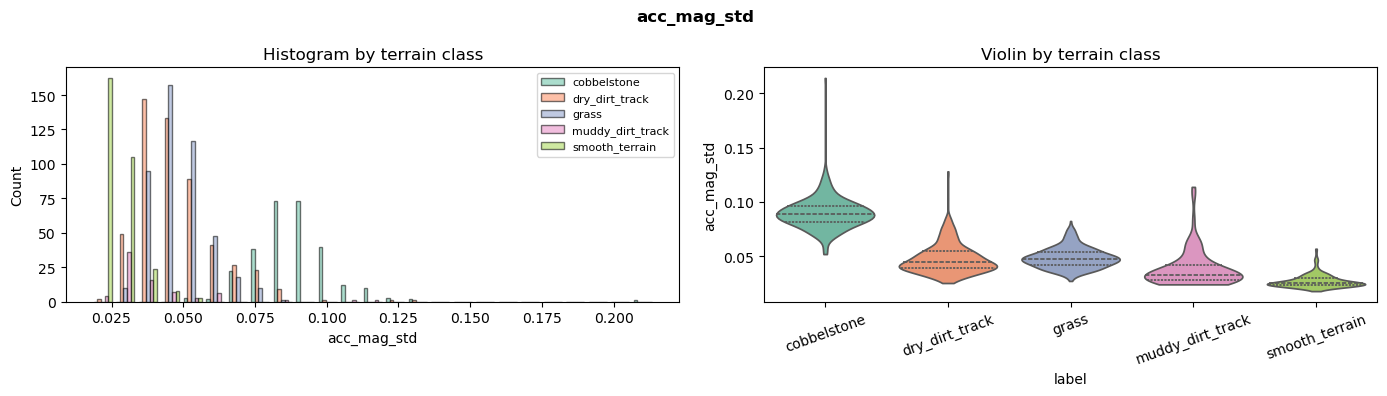

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


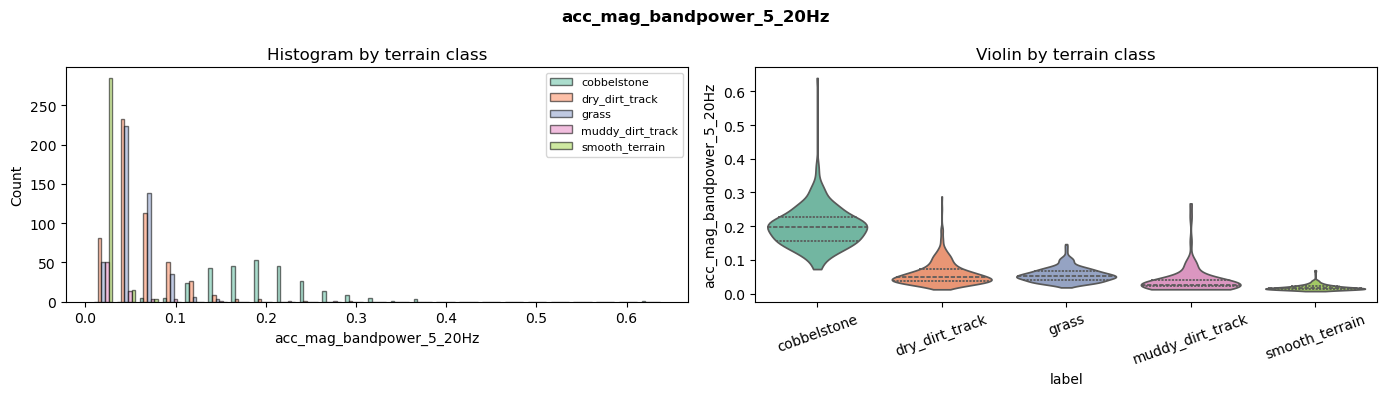

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


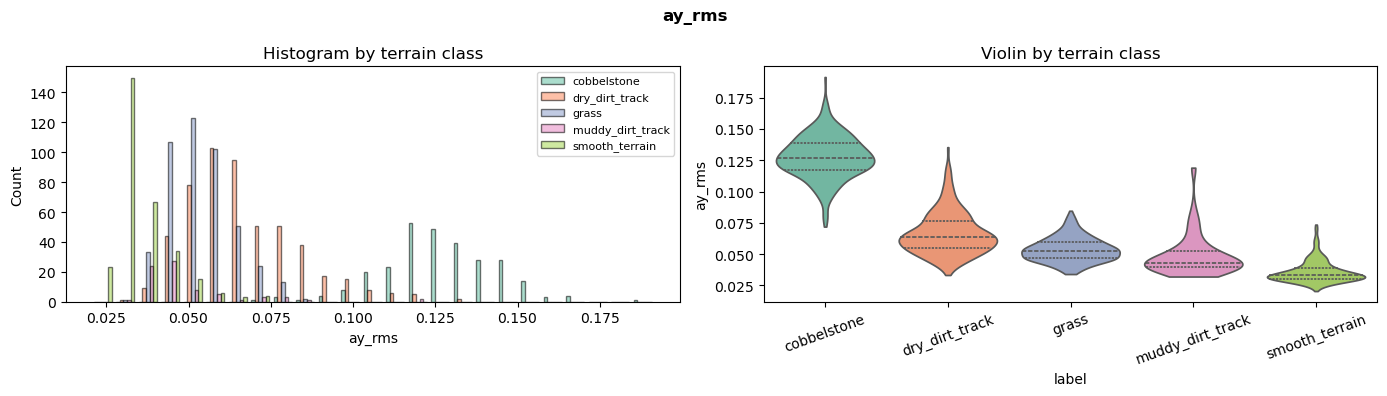

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


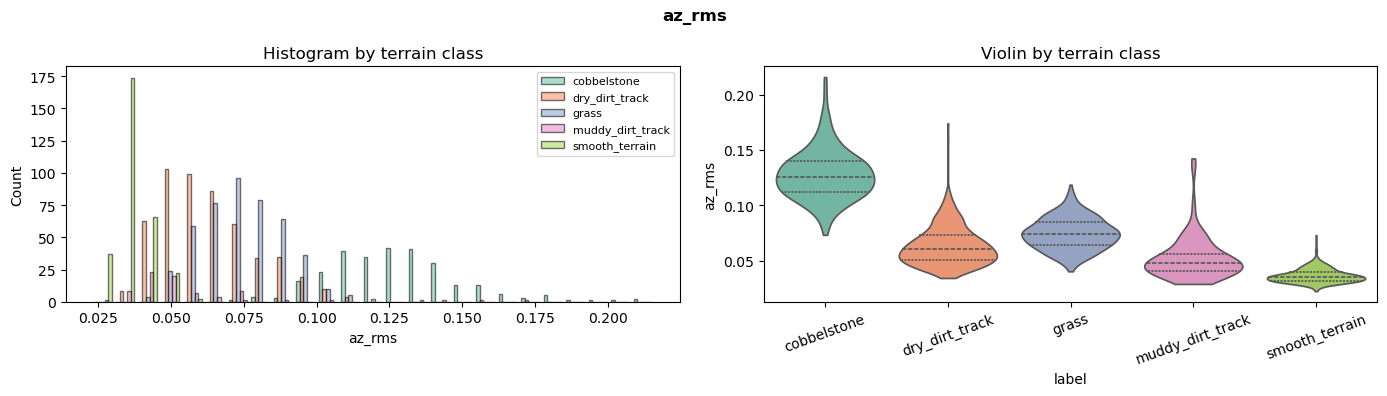

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


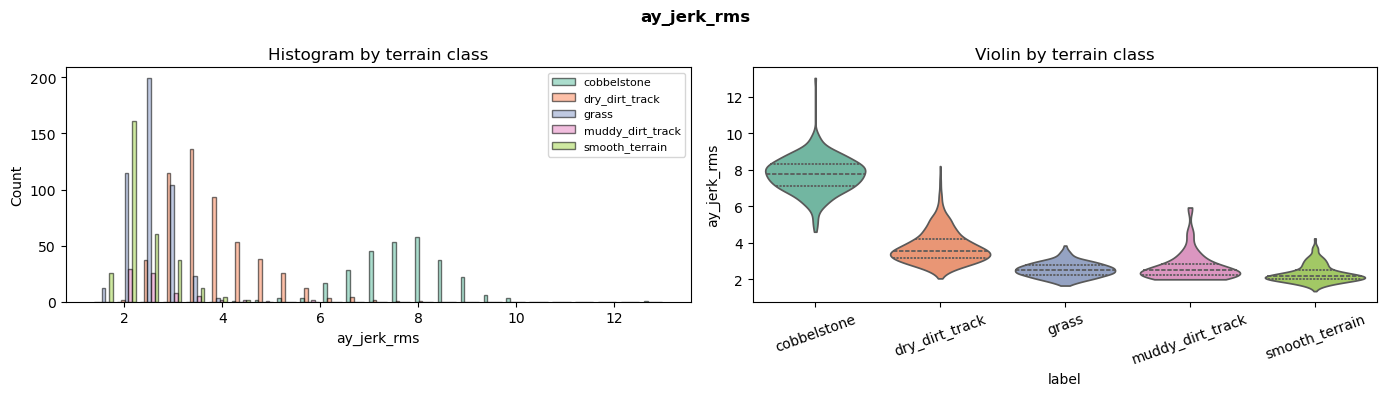

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


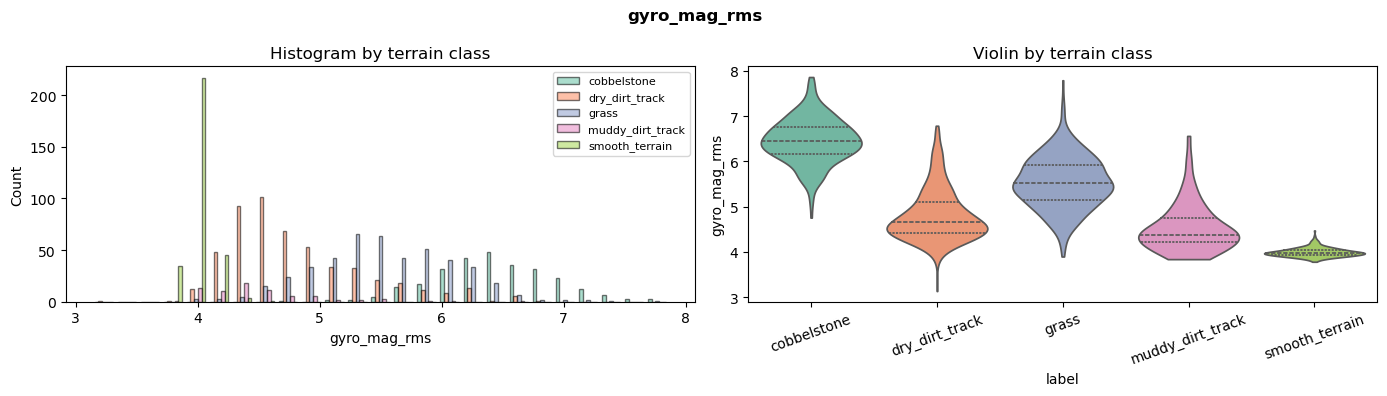

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


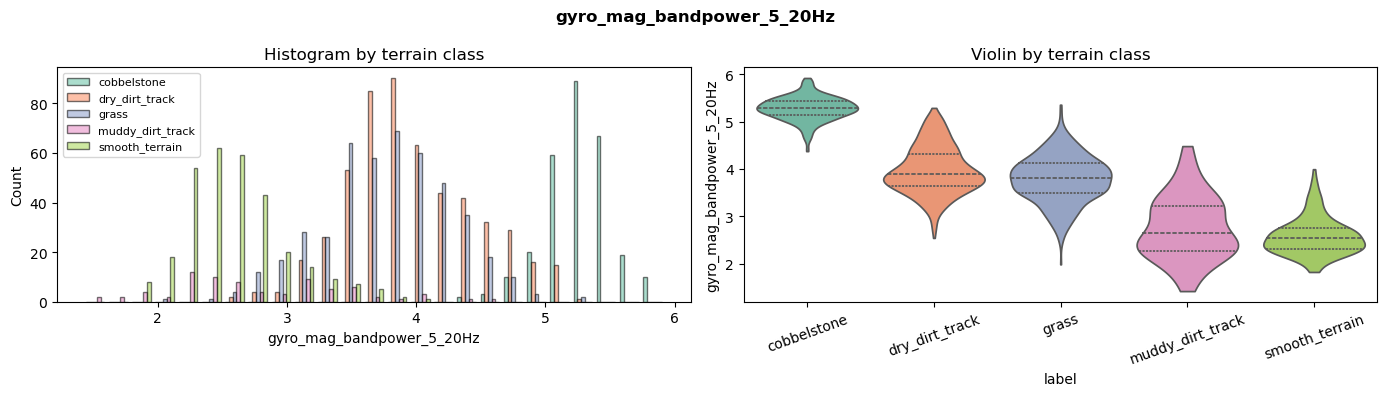

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


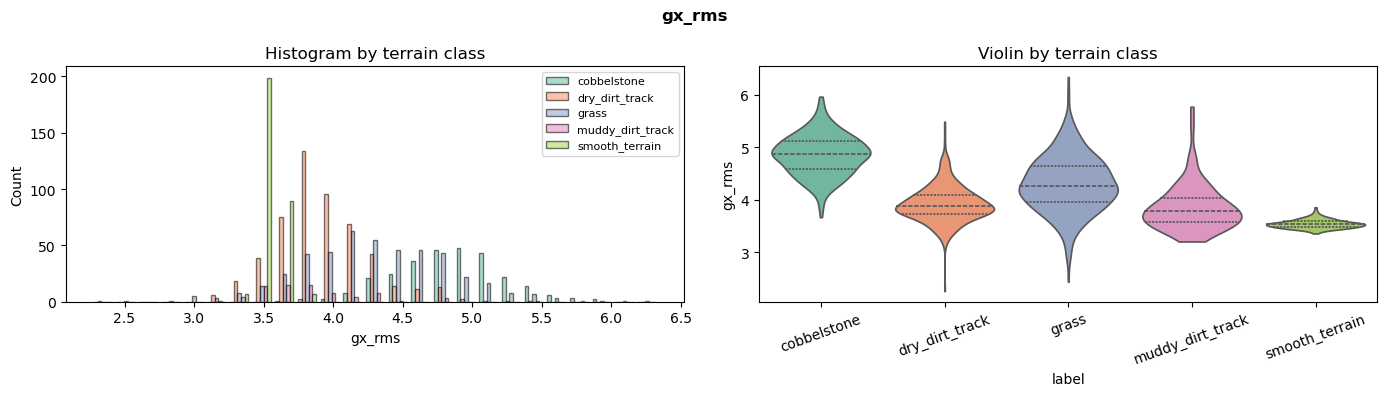

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


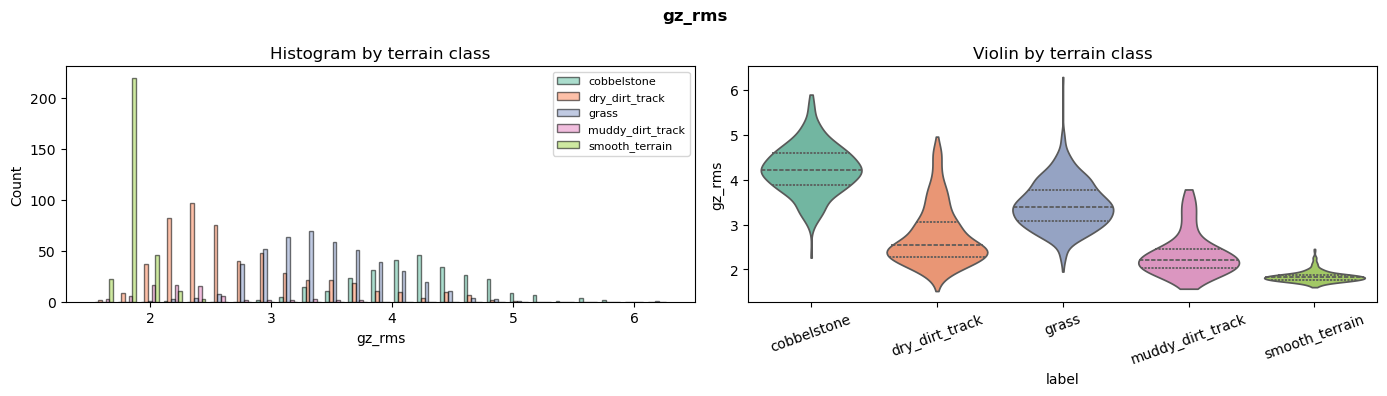

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


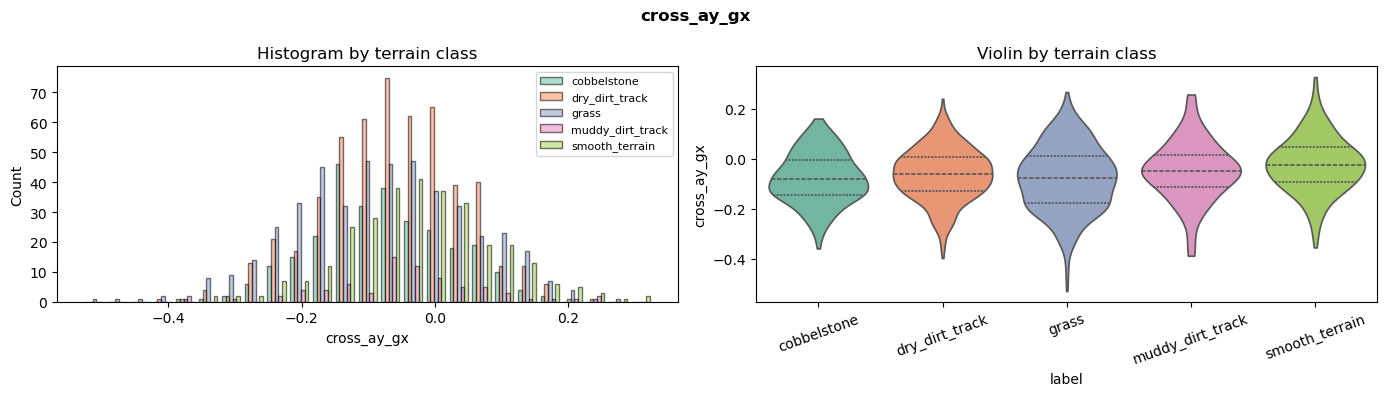

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


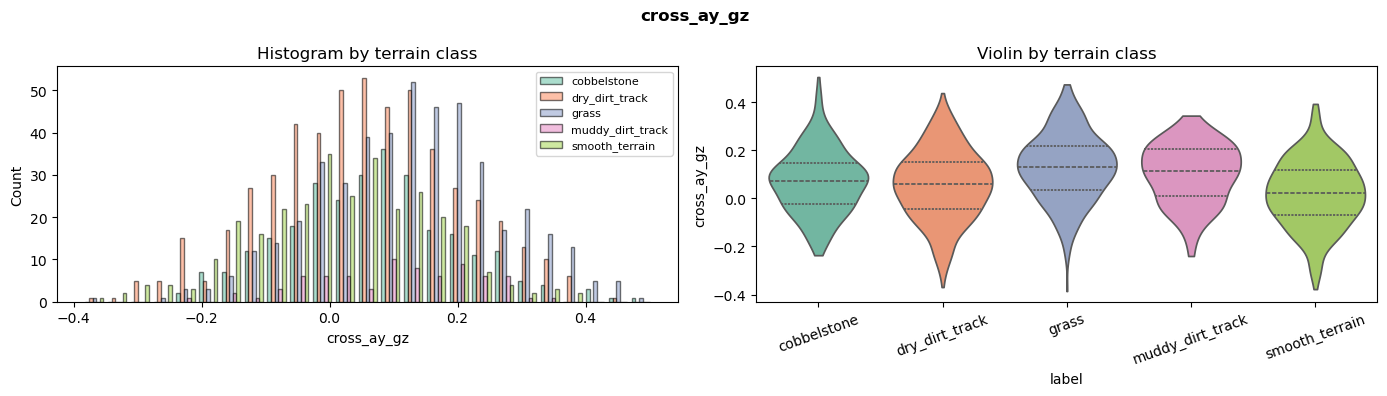

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


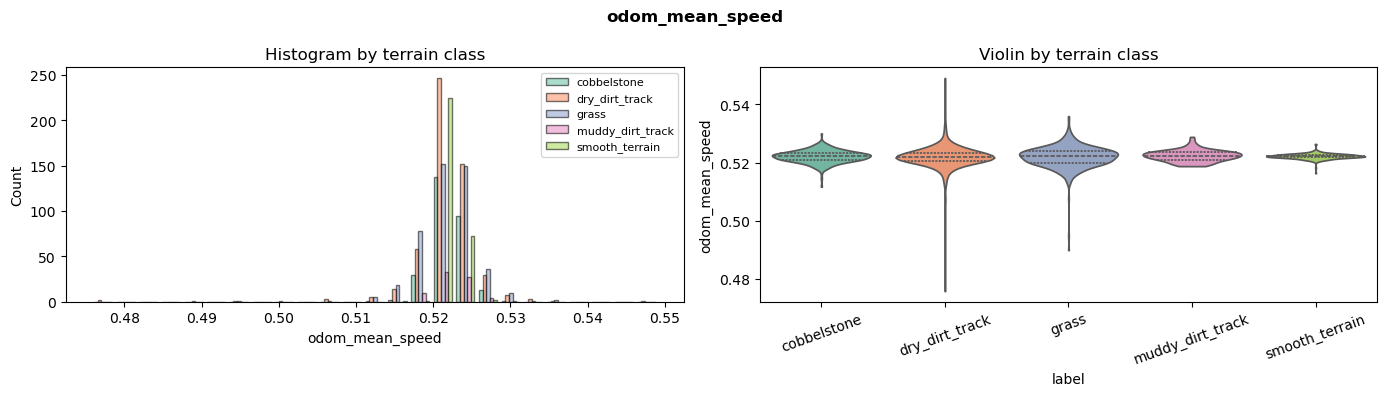

[plot_feature_distributions] Saved 13 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B


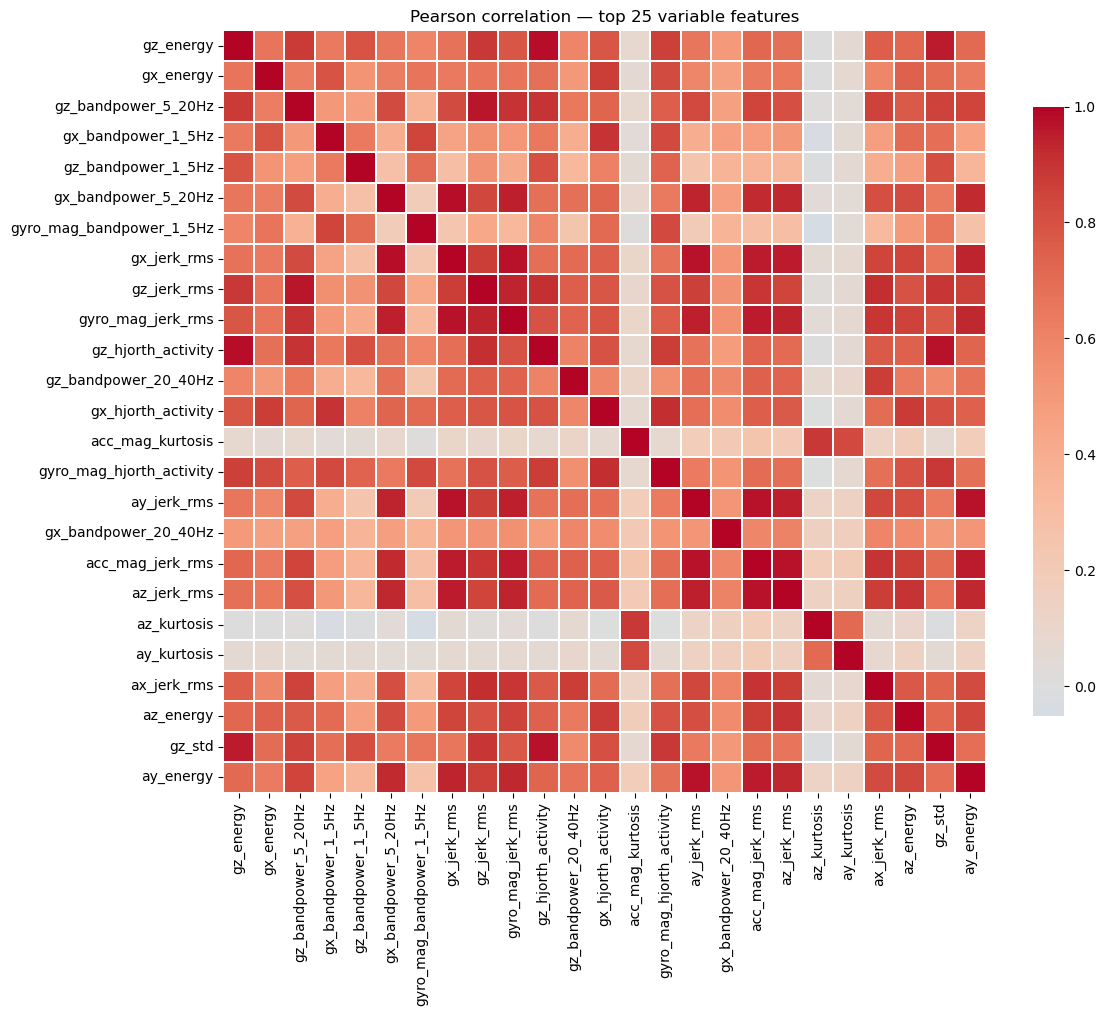


Top 15 absolute correlation pairs:
          feature_1          feature_2     corr
gx_bandpower_5_20Hz        gx_jerk_rms 0.980287
          gz_energy gz_hjorth_activity 0.979007
        ay_jerk_rms          ay_energy 0.973675
   acc_mag_jerk_rms        az_jerk_rms 0.972653
 gz_hjorth_activity             gz_std 0.972068
        gx_jerk_rms  gyro_mag_jerk_rms 0.970528
        ay_jerk_rms   acc_mag_jerk_rms 0.969118
        gx_jerk_rms        ay_jerk_rms 0.968559
gz_bandpower_5_20Hz        gz_jerk_rms 0.959045
   acc_mag_jerk_rms          ay_energy 0.956408
        gx_jerk_rms        az_jerk_rms 0.955561
          gz_energy             gz_std 0.955010
        gx_jerk_rms   acc_mag_jerk_rms 0.953760
  gyro_mag_jerk_rms   acc_mag_jerk_rms 0.950710
        ay_jerk_rms        az_jerk_rms 0.949638


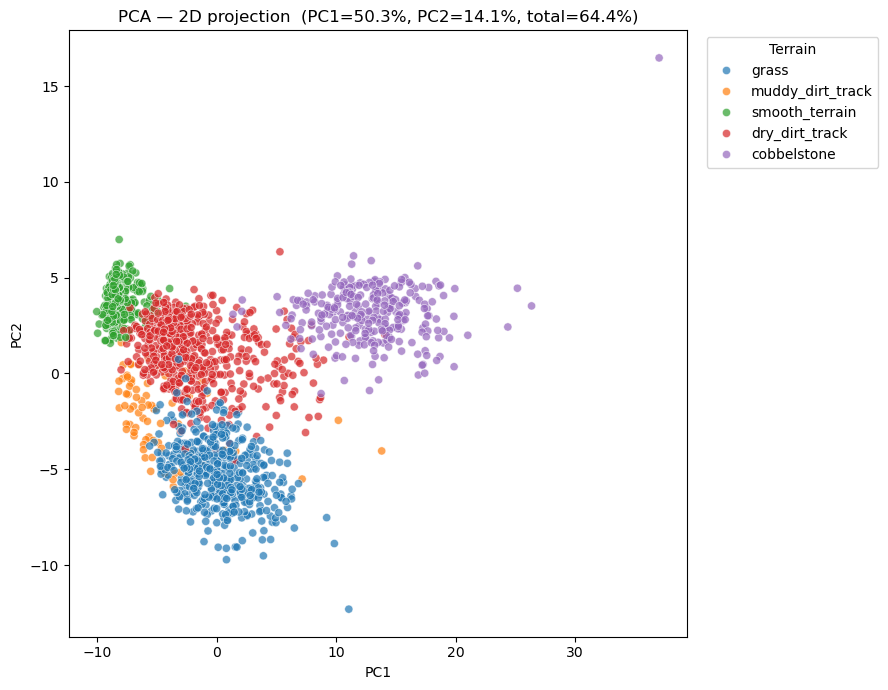

PCA explained variance: PC1=0.503, PC2=0.141, total=0.644


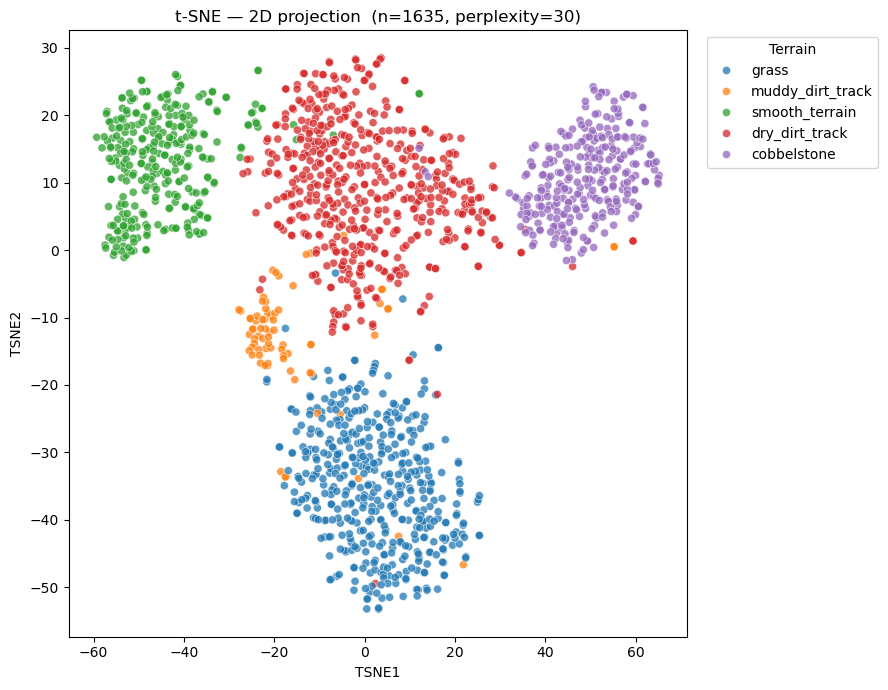

Dataset B EDA saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B


In [15]:
VIZ_FEATURES = [
    "acc_mag_rms", "acc_mag_std", "acc_mag_bandpower_5_20Hz",
    "ay_rms", "az_rms", "ay_jerk_rms",
    "gyro_mag_rms", "gyro_mag_bandpower_5_20Hz",
    "gx_rms", "gz_rms",
    "cross_ay_gx", "cross_ay_gz",
    "odom_mean_speed",
]
VIZ_FEATURES = [f for f in VIZ_FEATURES if f in dataset_A_tf.columns]

eval_A = None
eval_B = None

if RUN_EDA:
    reports_dir_A = PROJECT_ROOT / "reports" / "features" / "dataset_A"
    eda_feat_cols_A = get_eda_feature_columns(dataset_A_tf, id_cols=ID_COLS)
    eval_A = run_feature_evaluation(
        features_df=dataset_A_tf,
        reports_dir=reports_dir_A,
        viz_features=VIZ_FEATURES,
        label_col="label",
        id_cols=ID_COLS,
        feature_cols=eda_feat_cols_A,
        top_n_heatmap=TOP_N_HEATMAP,
        random_state=RANDOM_STATE,
        tsne_sample_cap=TSNE_SAMPLE_CAP,
        show=True,
    )
    print(f"Dataset A EDA saved -> {reports_dir_A}")

    if dataset_B_tf is not None:
        reports_dir_B = PROJECT_ROOT / "reports" / "features" / "dataset_B"
        eda_feat_cols_B = get_eda_feature_columns(dataset_B_tf, id_cols=ID_COLS)
        eval_B = run_feature_evaluation(
            features_df=dataset_B_tf,
            reports_dir=reports_dir_B,
            viz_features=[f for f in VIZ_FEATURES if f in dataset_B_tf.columns],
            label_col="label",
            id_cols=ID_COLS,
            feature_cols=eda_feat_cols_B,
            top_n_heatmap=TOP_N_HEATMAP,
            random_state=RANDOM_STATE,
            tsne_sample_cap=TSNE_SAMPLE_CAP,
            show=True,
        )
        print(f"Dataset B EDA saved -> {reports_dir_B}")
    else:
        print("Dataset B EDA skipped (Dataset B unavailable).")
else:
    print("RUN_EDA=False -> skipping EDA cells.")

## Cell 6 — Merged-label EDA (guarded by RUN_MERGED_LABEL_EDA)

This optional exploratory branch merges dry and muddy dirt labels for visualization experiments without changing downstream training artifacts.

FEATURE TABLE DIAGNOSTICS
  Shape          : (2346, 196)
  Feature count  : 103
  Missing values : 0 total

  Label distribution (label):
                count  pct_%
label                       
cobbelstone       355  15.13
dirt_track        797  33.97
grass             488  20.80
smooth_terrain    706  30.09

  Per-class mean of key features:
                acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  ay_jerk_rms  gz_jerk_rms  cross_ay_gx  cross_ay_gz
label                                                                                                                                   
cobbelstone          0.2590       0.1135          2.5418        6.9629        3.0285       9.7973     205.2919      -0.0552       0.0402
dirt_track           0.1552       0.0695          1.6070        5.3379        2.0782       5.5323     118.7337      -0.0593       0.0272
grass                0.1374       0.0588          1.4478        5.9566        2.4770       3.4085     110

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


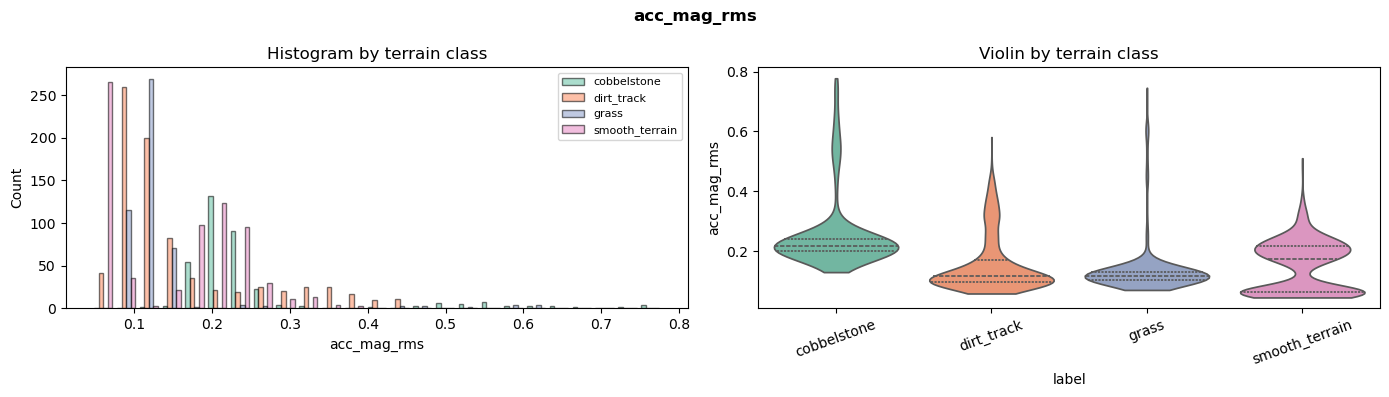

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


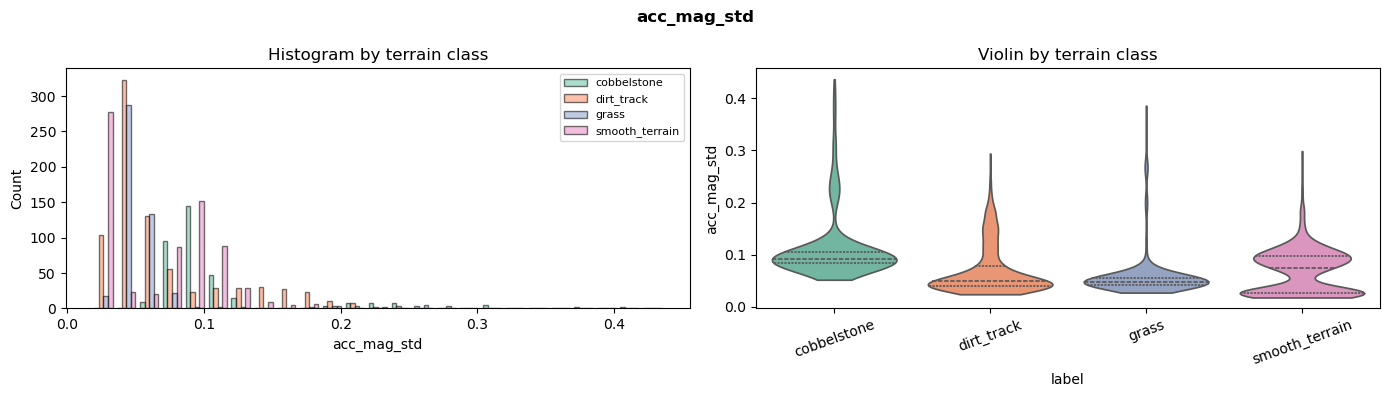

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


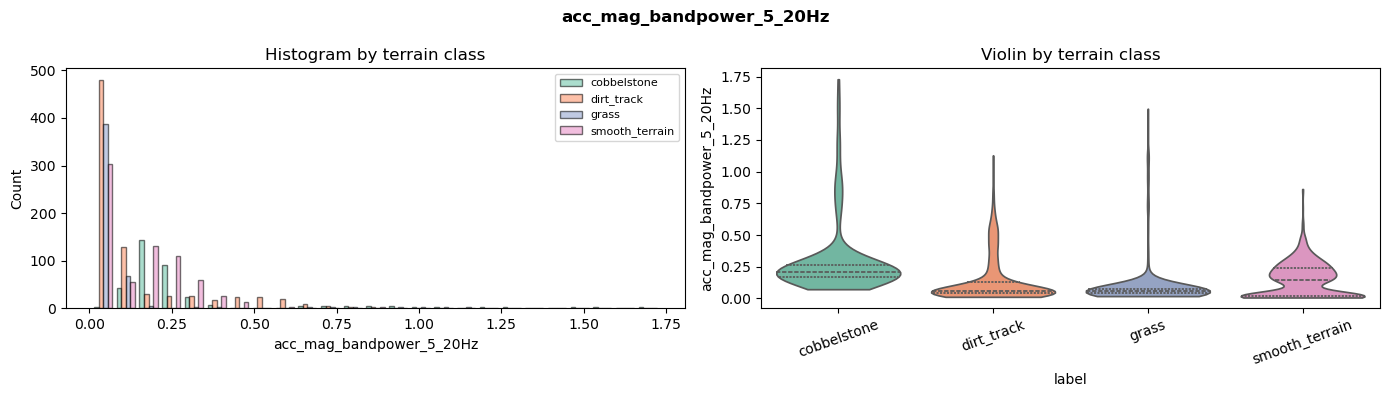

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


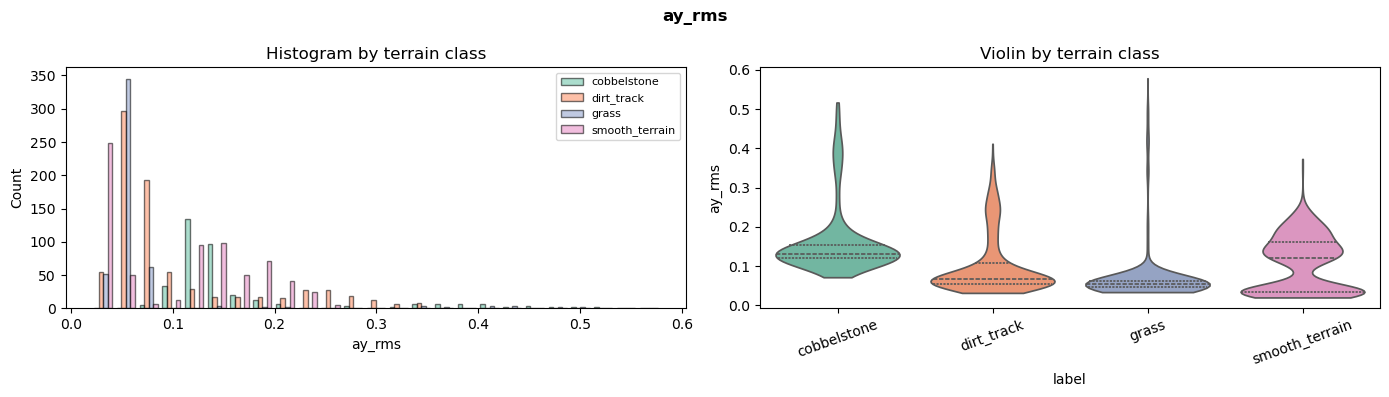

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


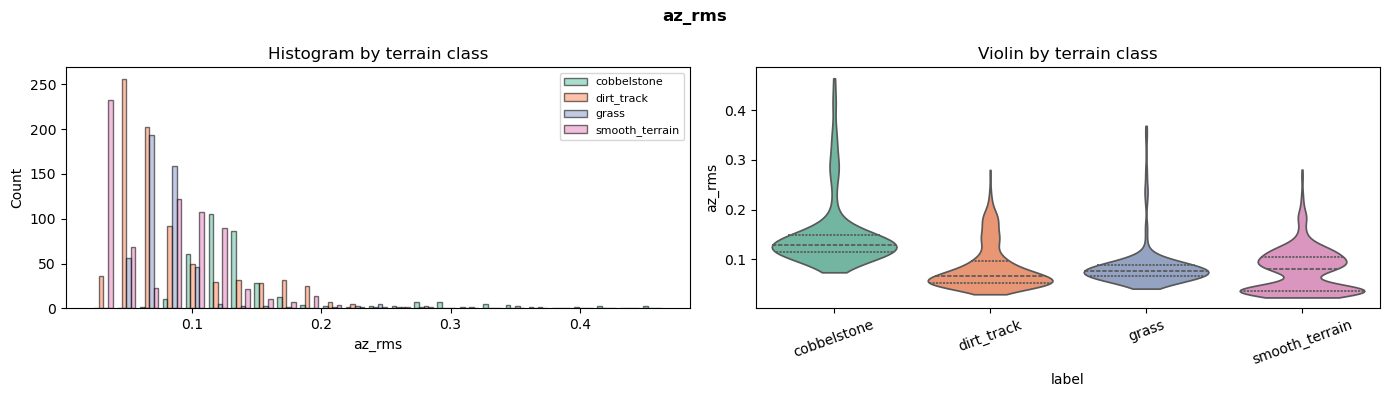

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


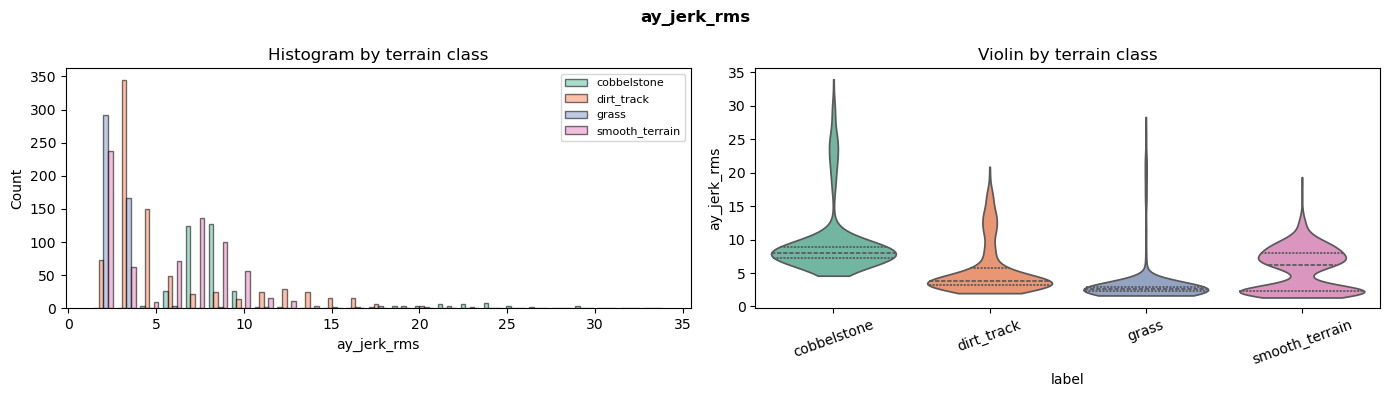

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


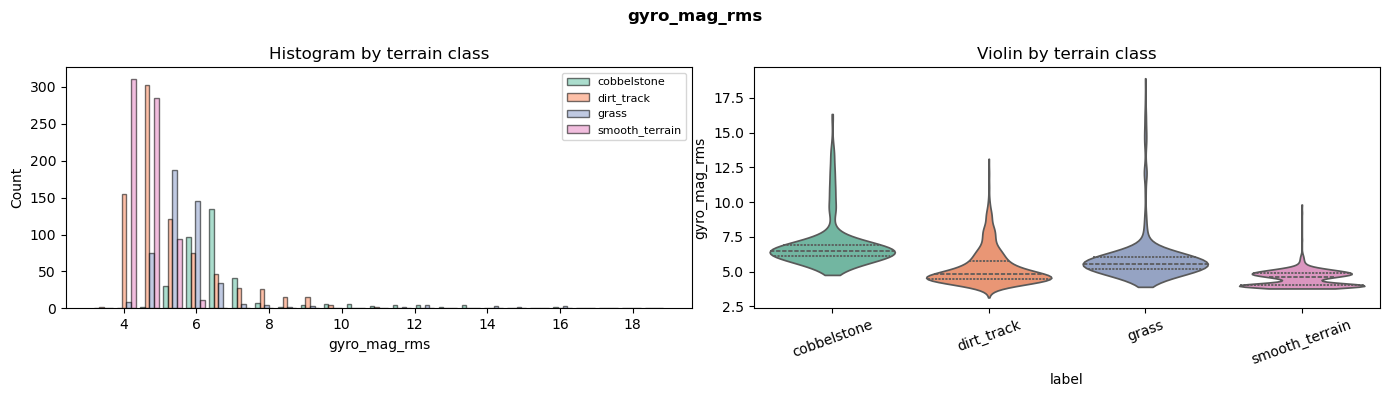

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


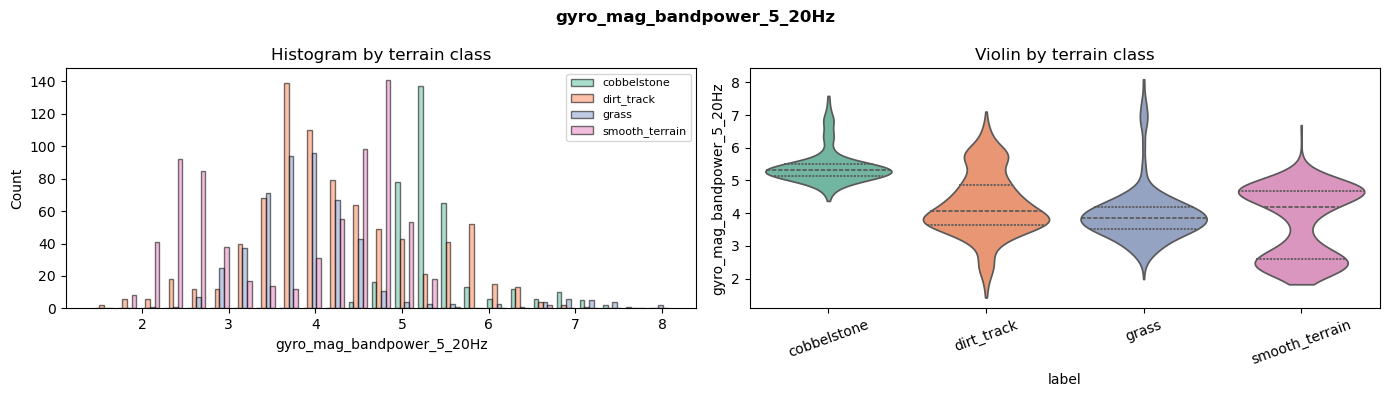

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


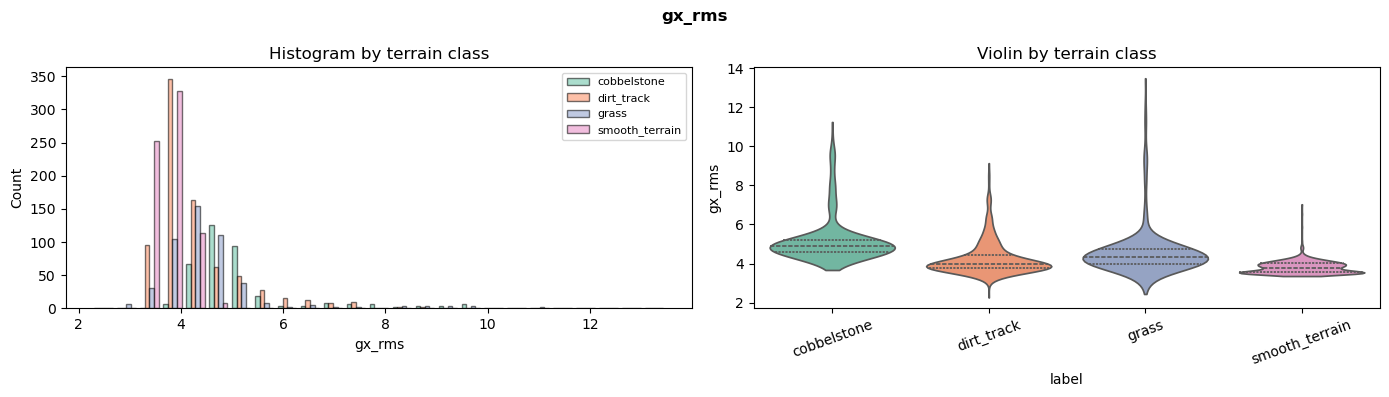

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


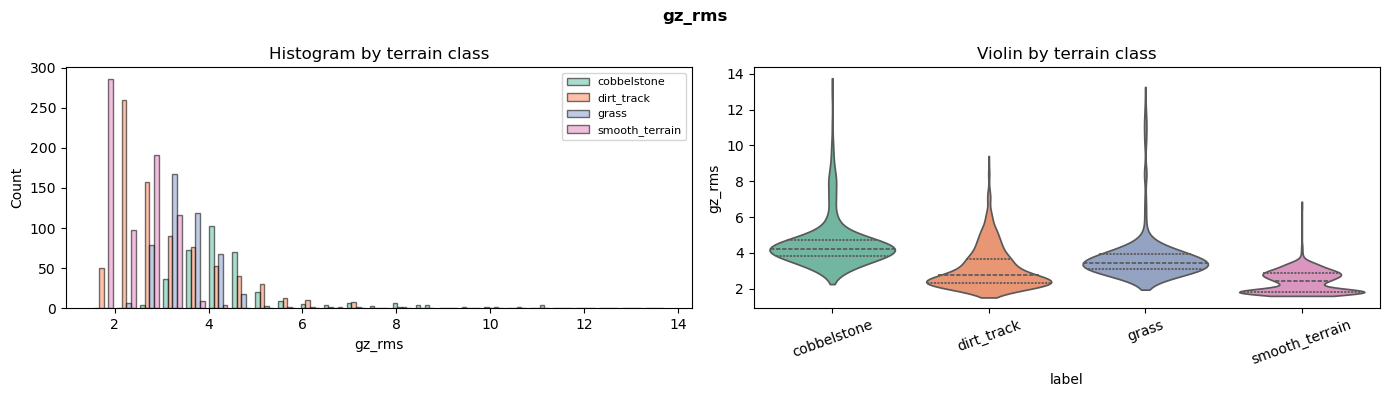

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


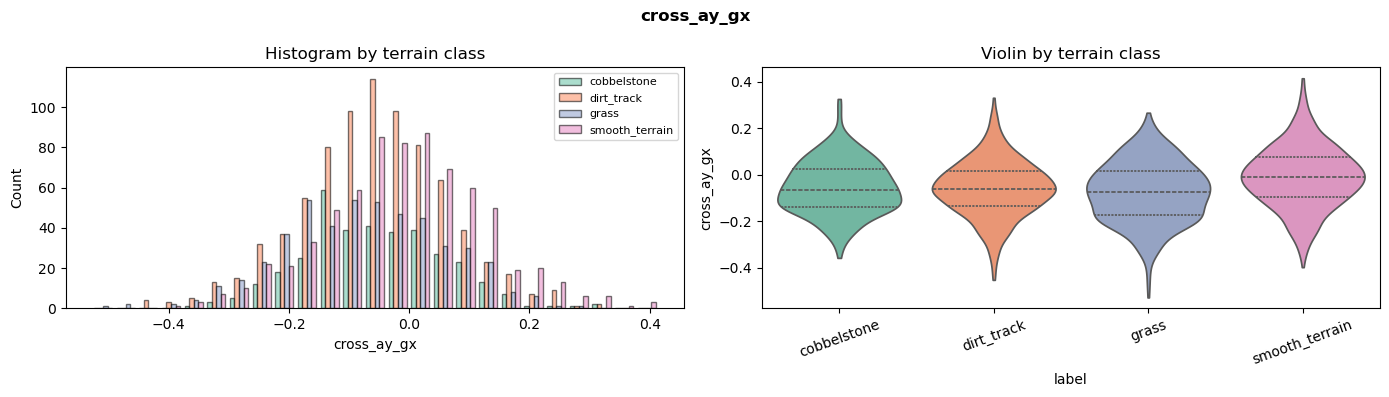

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


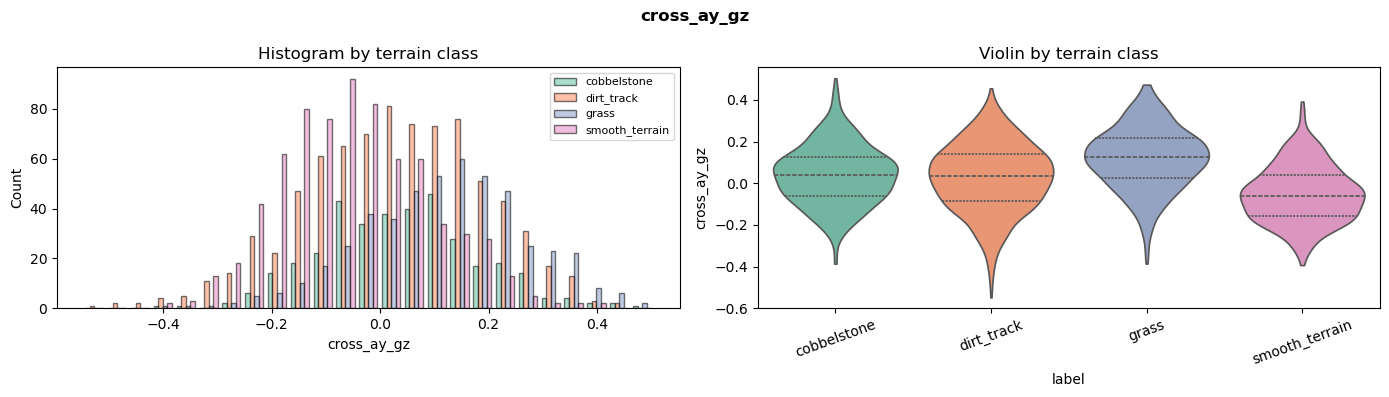

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


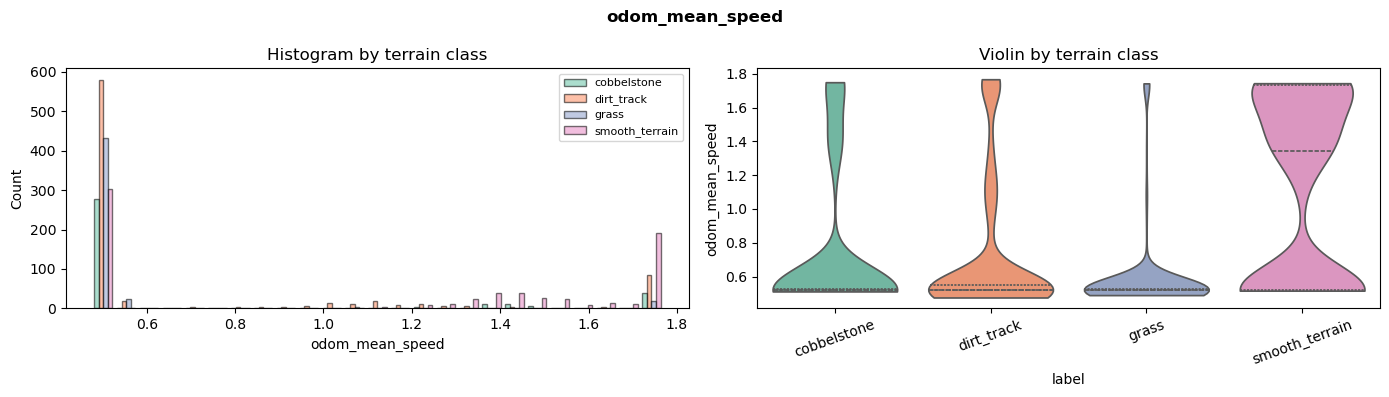

[plot_feature_distributions] Saved 13 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A_merged_dirt


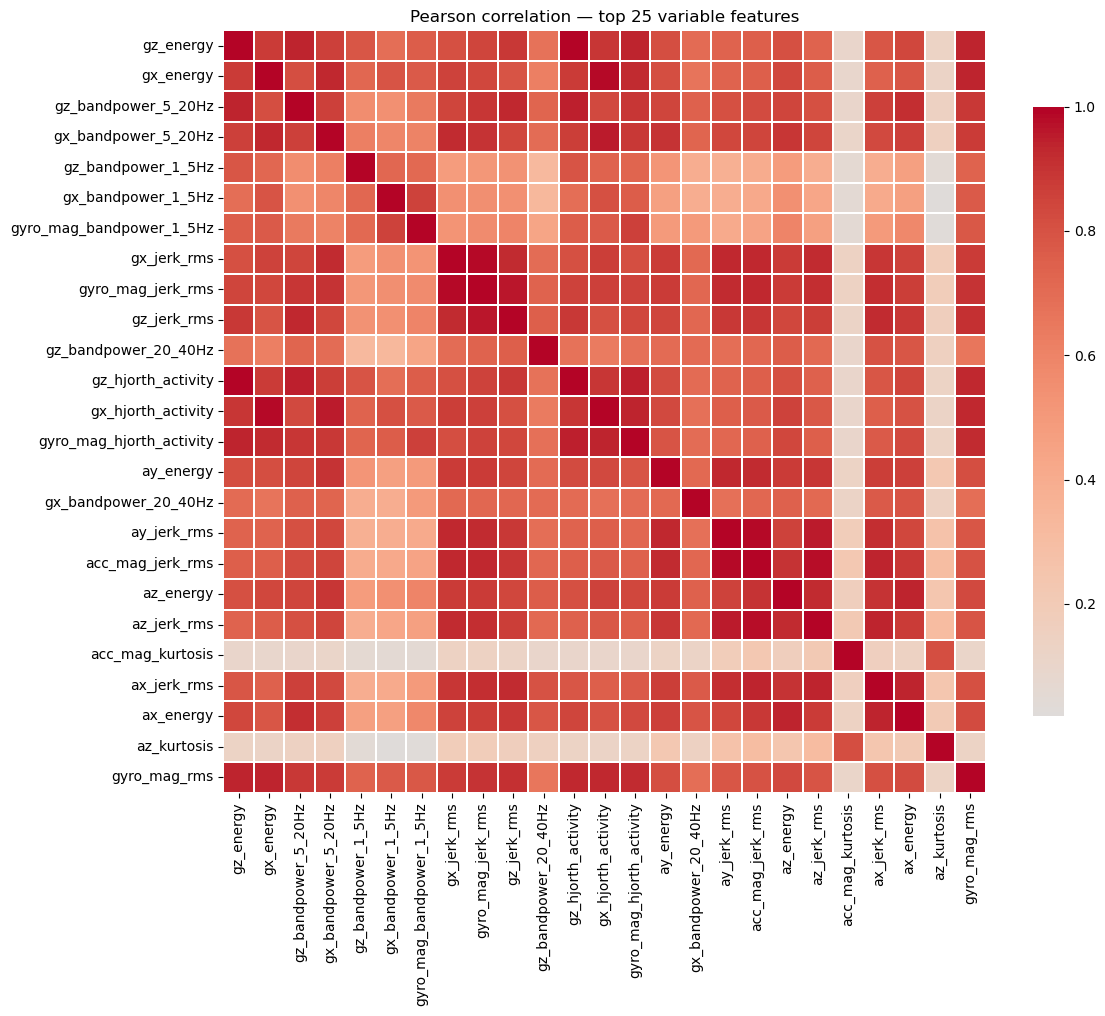


Top 15 absolute correlation pairs:
          feature_1                feature_2     corr
          gz_energy       gz_hjorth_activity 0.995303
        ay_jerk_rms         acc_mag_jerk_rms 0.984733
        gx_jerk_rms        gyro_mag_jerk_rms 0.982532
          gx_energy       gx_hjorth_activity 0.982373
   acc_mag_jerk_rms              az_jerk_rms 0.977023
  gyro_mag_jerk_rms              gz_jerk_rms 0.961321
        ay_jerk_rms              az_jerk_rms 0.955200
gx_bandpower_5_20Hz       gx_hjorth_activity 0.950570
gz_bandpower_5_20Hz       gz_hjorth_activity 0.946513
 gz_hjorth_activity gyro_mag_hjorth_activity 0.943814
   acc_mag_jerk_rms              ax_jerk_rms 0.941782
          gz_energy gyro_mag_hjorth_activity 0.941172
          gz_energy      gz_bandpower_5_20Hz 0.940717
          az_energy                ax_energy 0.938025
          gz_energy             gyro_mag_rms 0.937292


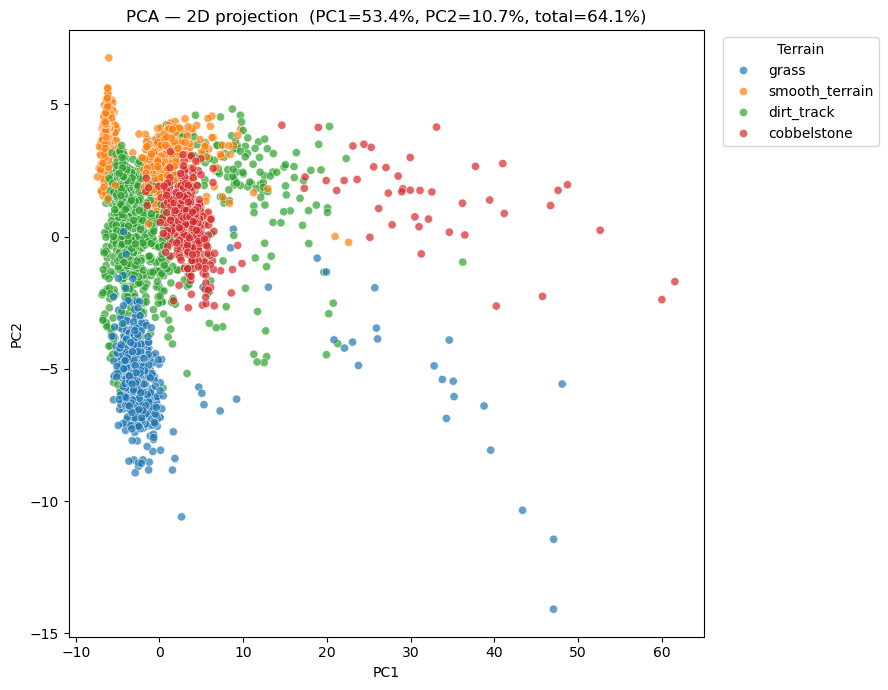

PCA explained variance: PC1=0.534, PC2=0.107, total=0.641


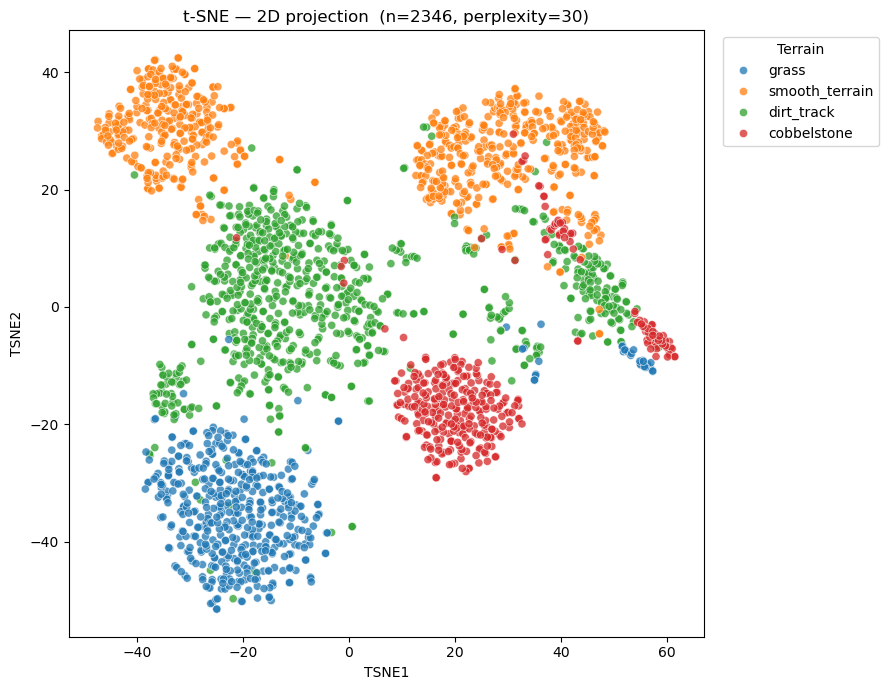

Merged-label Dataset A EDA saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A_merged_dirt
FEATURE TABLE DIAGNOSTICS
  Shape          : (1635, 196)
  Feature count  : 103
  Missing values : 0 total

  Label distribution (label):
                count  pct_%
label                       
cobbelstone       279  17.06
dirt_track        598  36.57
grass             456  27.89
smooth_terrain    302  18.47

  Per-class mean of key features:
                acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  ay_jerk_rms  gz_jerk_rms  cross_ay_gx  cross_ay_gz
label                                                                                                                                   
cobbelstone          0.2114       0.0897          2.2858        6.4579        2.7289       7.7350     180.1687      -0.0776       0.0713
dirt_track           0.1093       0.0468          1.2031        4.7806        1.7256  

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


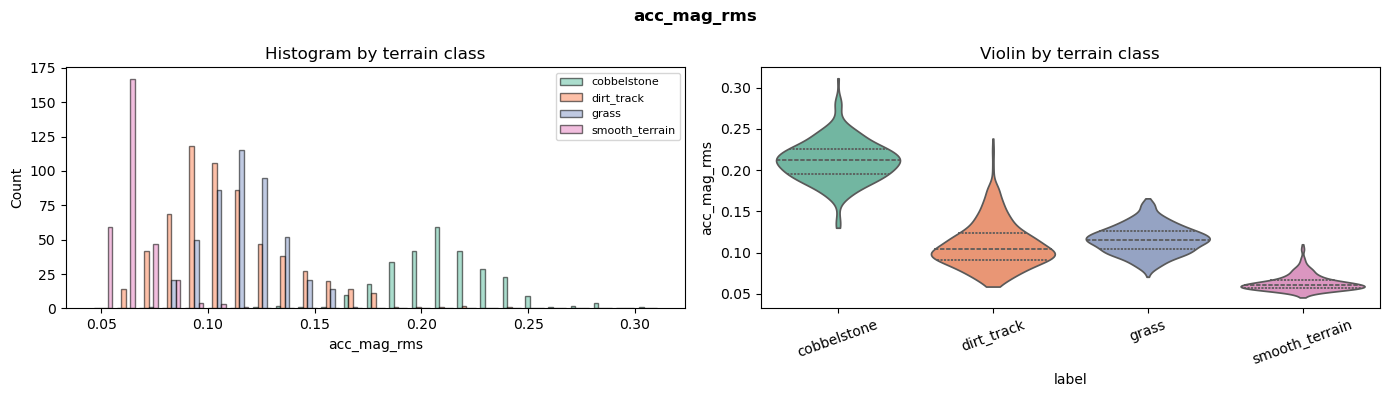

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


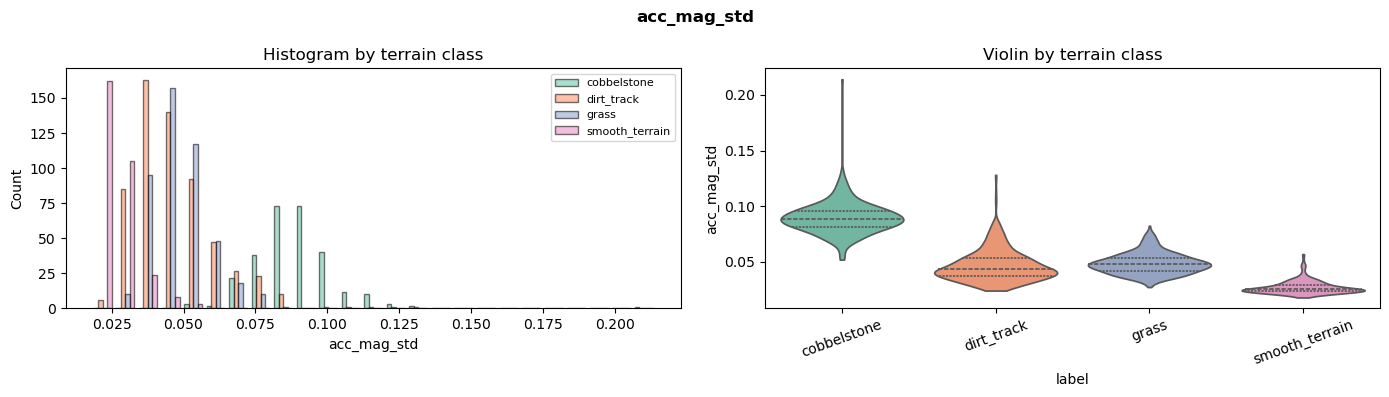

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


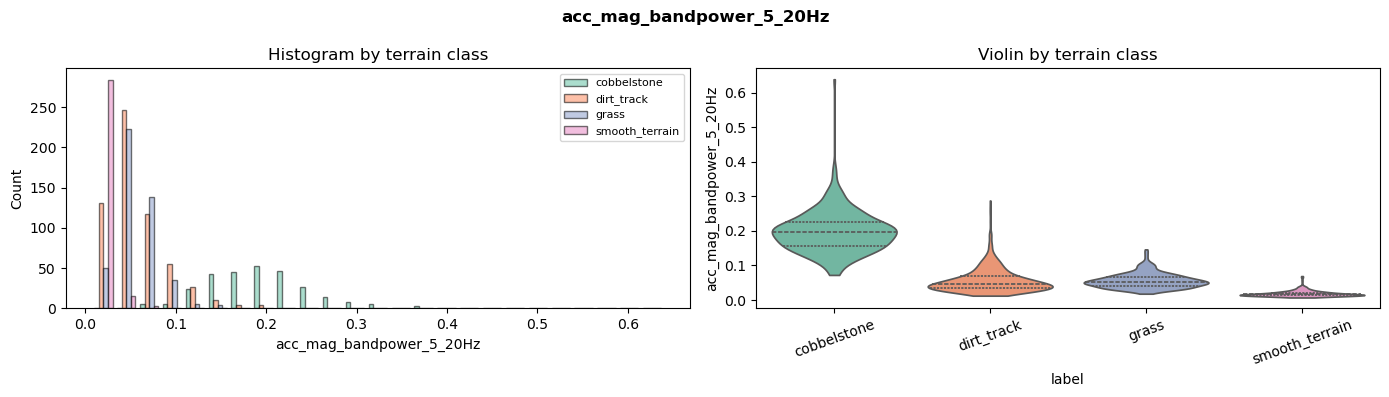

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


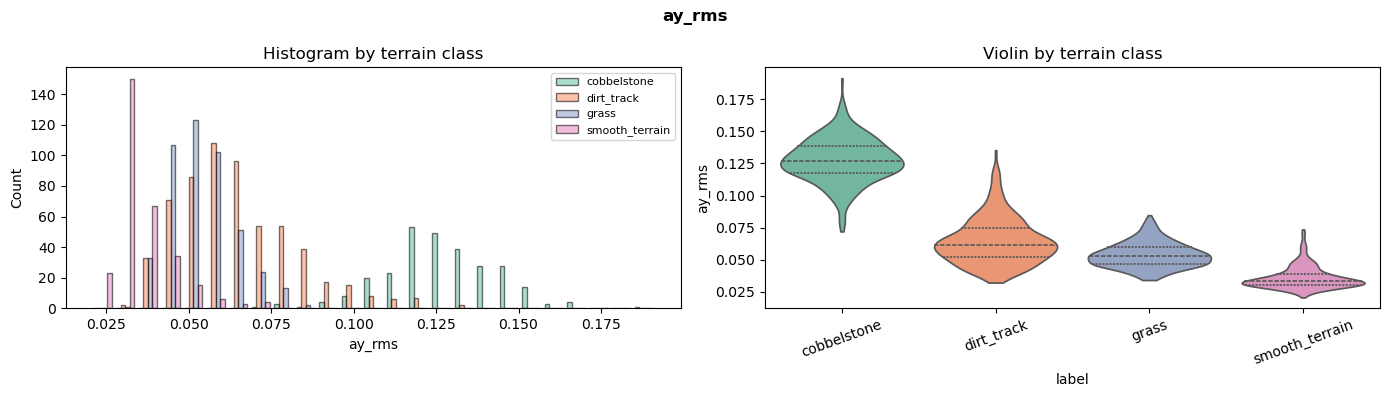

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


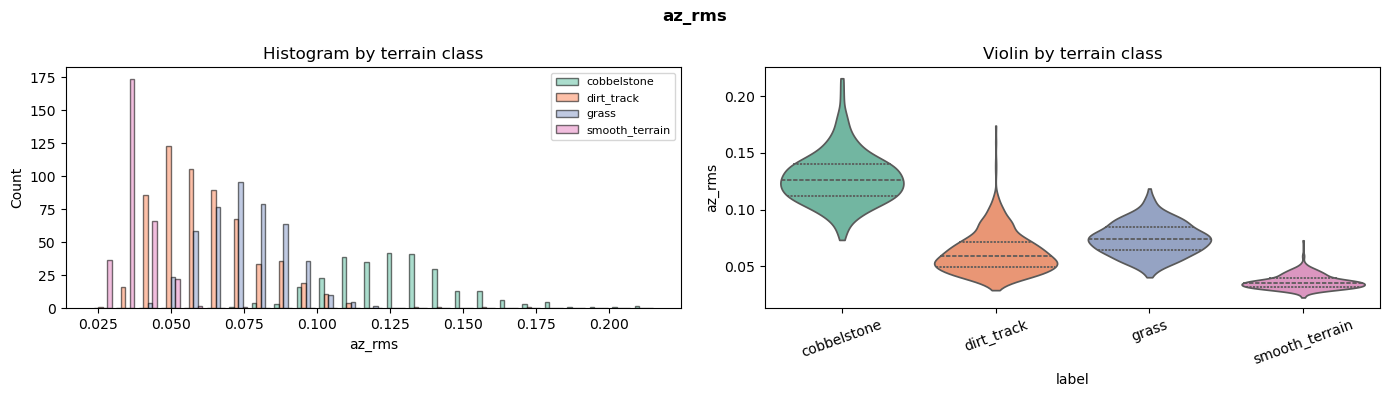

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


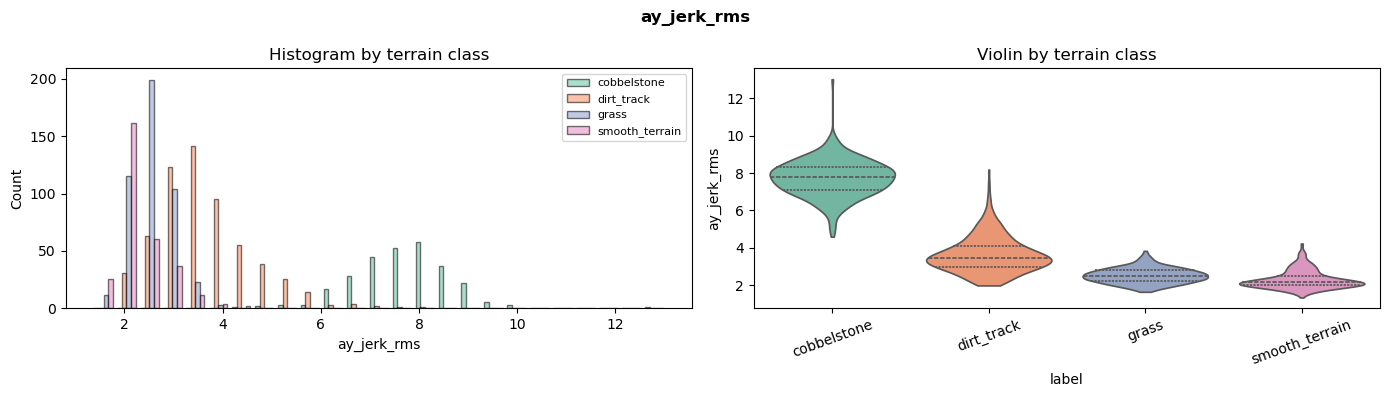

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


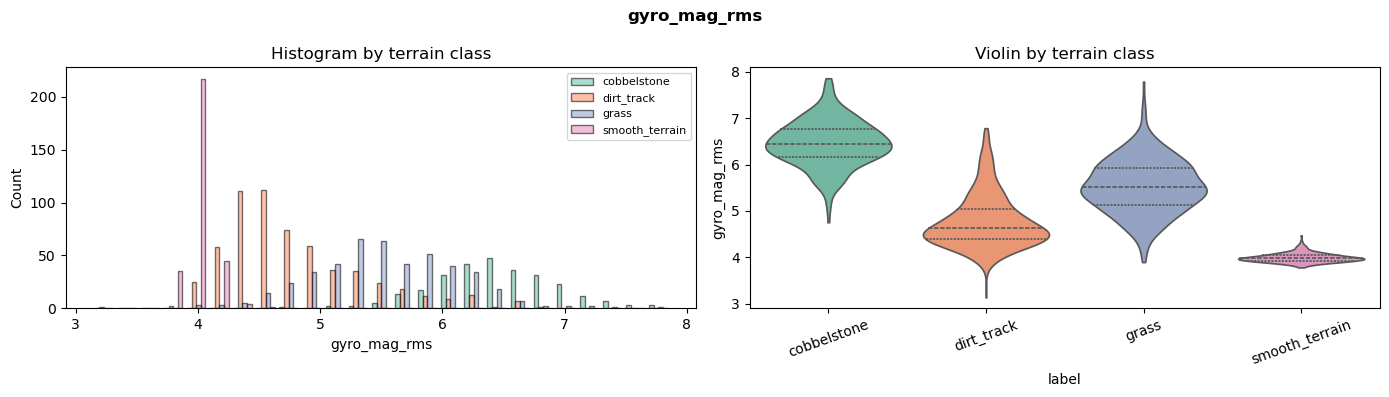

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


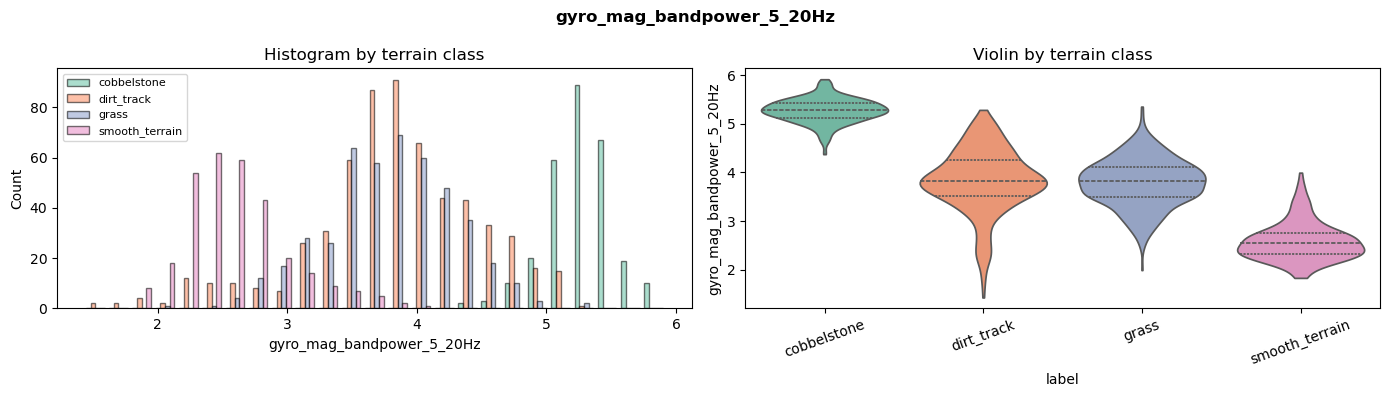

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


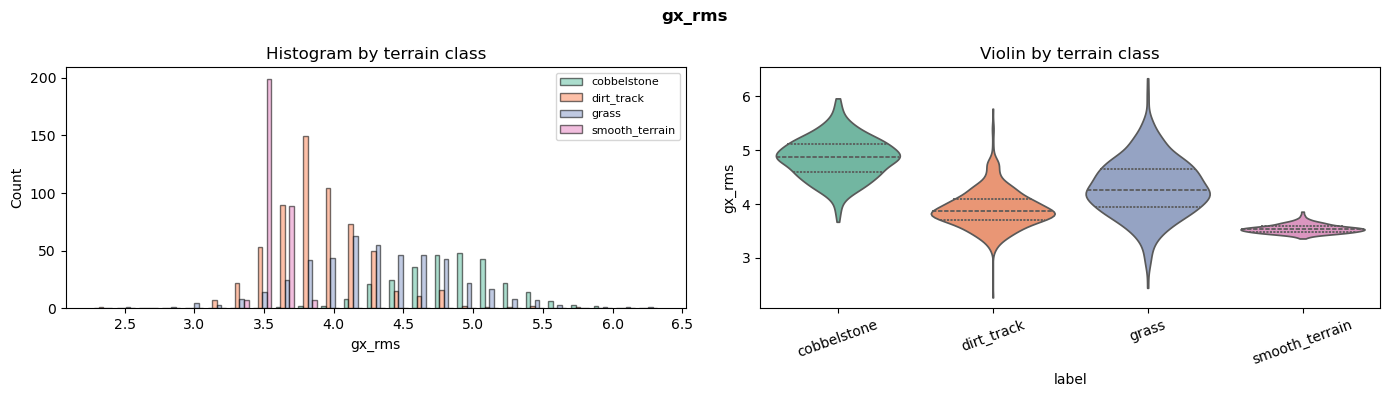

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


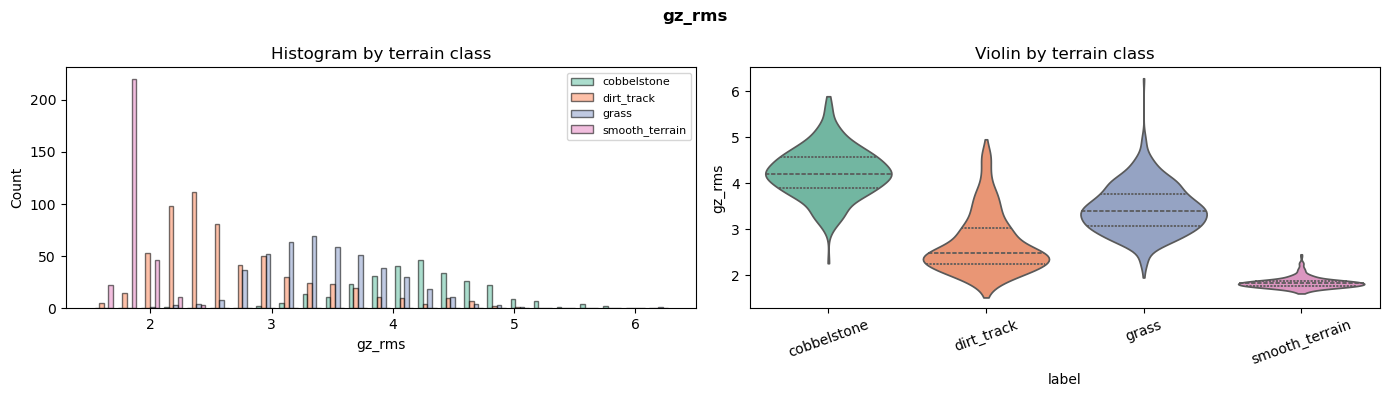

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


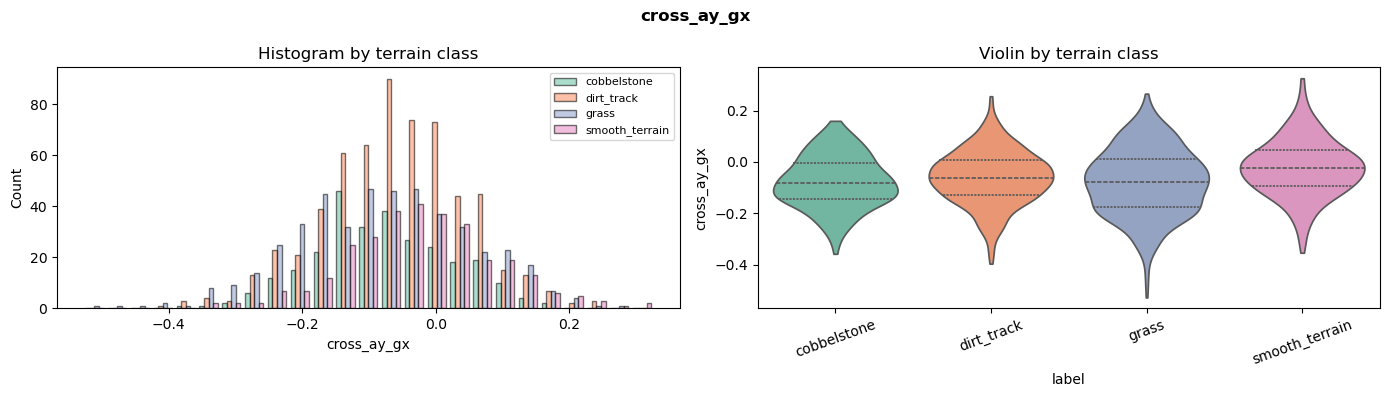

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


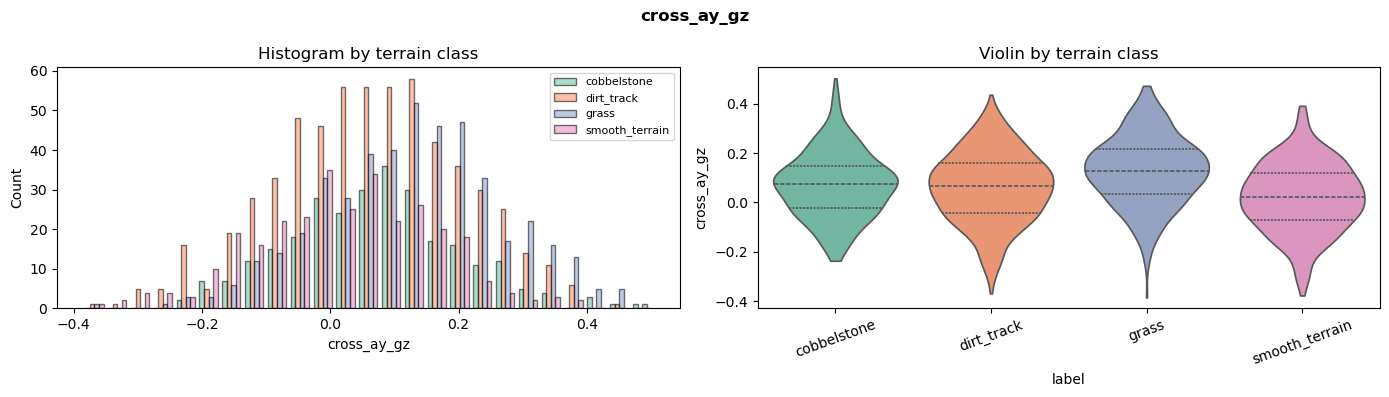

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:817: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


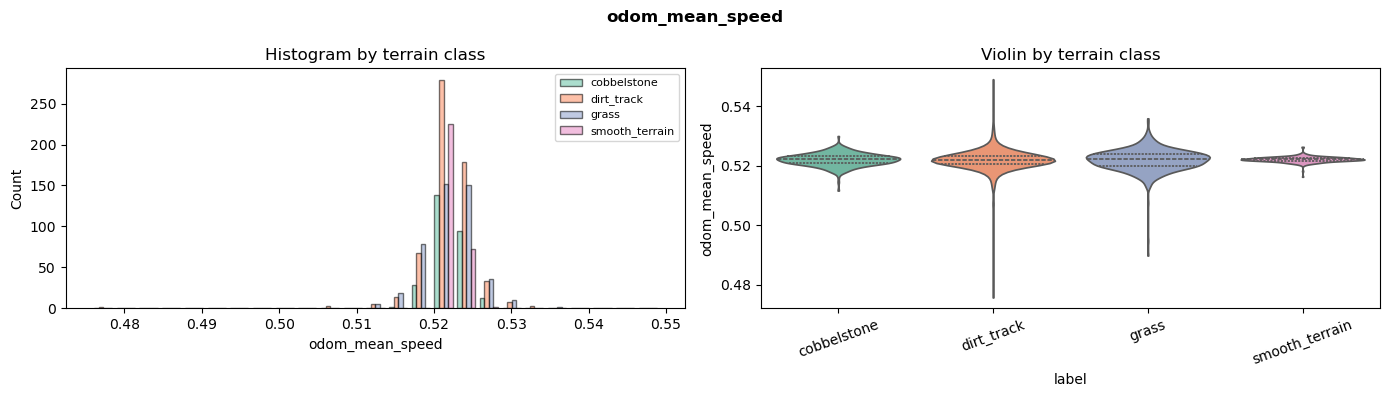

[plot_feature_distributions] Saved 13 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_merged_dirt


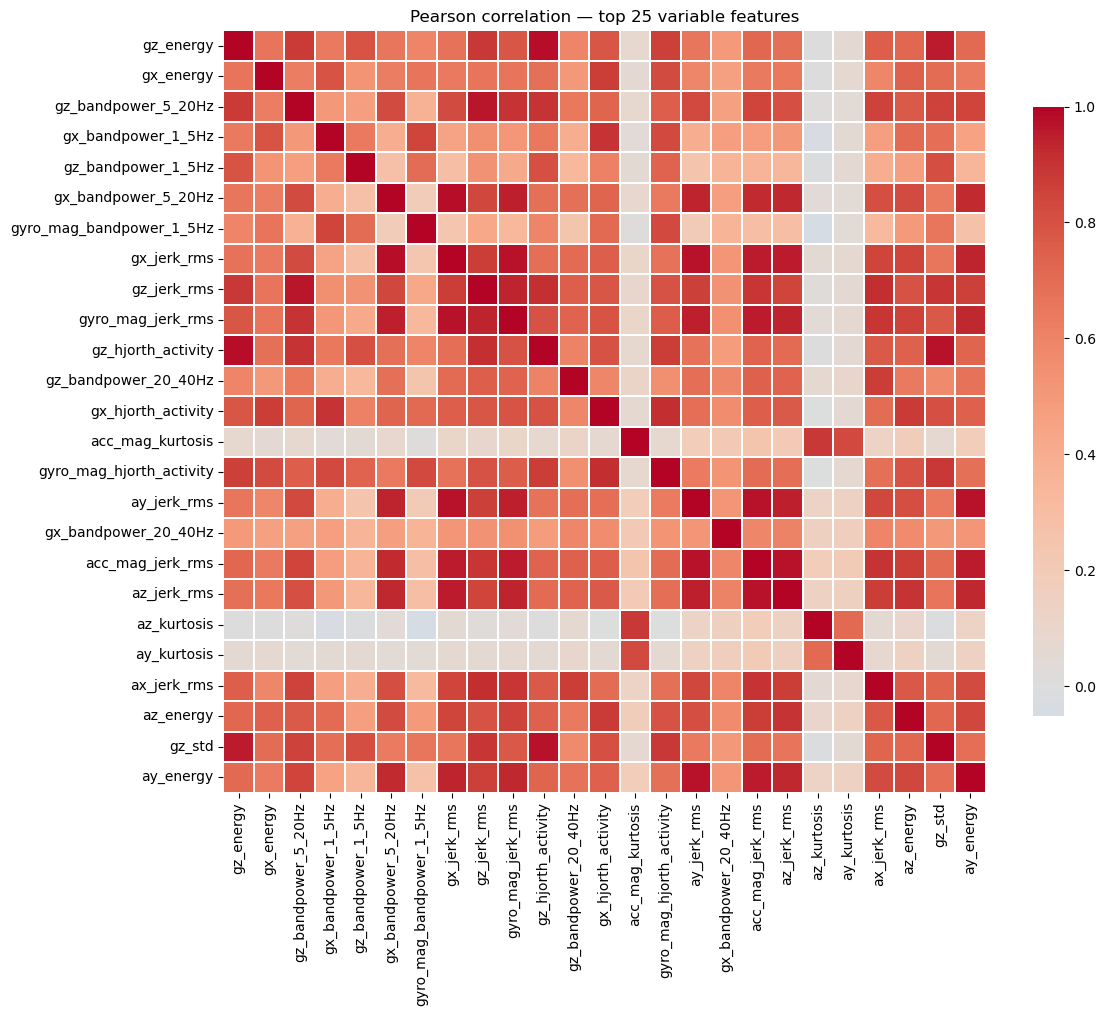


Top 15 absolute correlation pairs:
          feature_1          feature_2     corr
gx_bandpower_5_20Hz        gx_jerk_rms 0.980287
          gz_energy gz_hjorth_activity 0.979007
        ay_jerk_rms          ay_energy 0.973675
   acc_mag_jerk_rms        az_jerk_rms 0.972653
 gz_hjorth_activity             gz_std 0.972068
        gx_jerk_rms  gyro_mag_jerk_rms 0.970528
        ay_jerk_rms   acc_mag_jerk_rms 0.969118
        gx_jerk_rms        ay_jerk_rms 0.968559
gz_bandpower_5_20Hz        gz_jerk_rms 0.959045
   acc_mag_jerk_rms          ay_energy 0.956408
        gx_jerk_rms        az_jerk_rms 0.955561
          gz_energy             gz_std 0.955010
        gx_jerk_rms   acc_mag_jerk_rms 0.953760
  gyro_mag_jerk_rms   acc_mag_jerk_rms 0.950710
        ay_jerk_rms        az_jerk_rms 0.949638


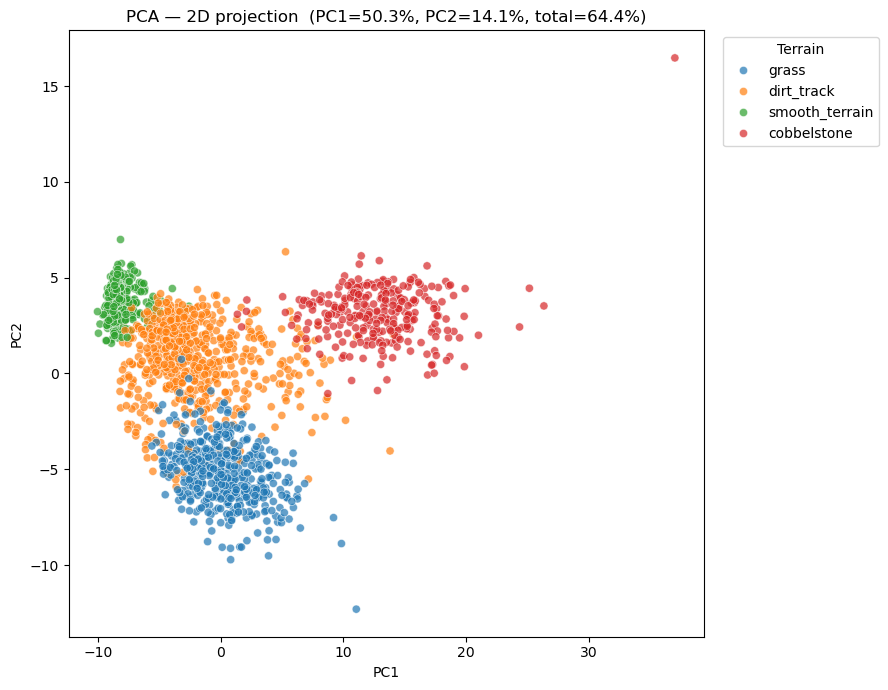

PCA explained variance: PC1=0.503, PC2=0.141, total=0.644


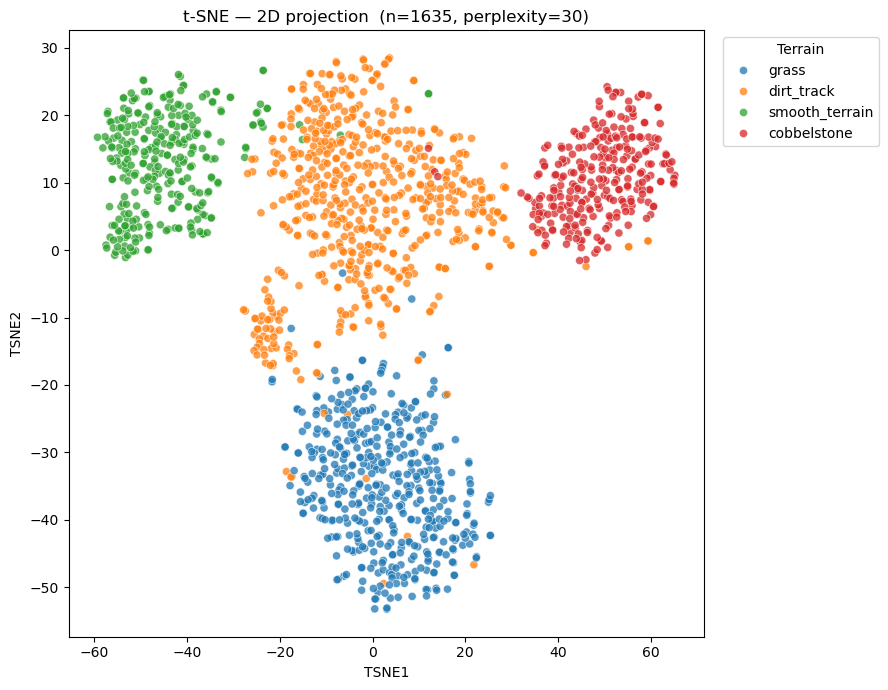

Merged-label Dataset B EDA saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_merged_dirt
Note: merged-label EDA is exploratory only and does not affect downstream cells.


In [16]:
if RUN_MERGED_LABEL_EDA:
    def merge_dirt_labels(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out["label"] = out["label"].replace({lbl: MERGED_DIRT_LABEL for lbl in DIRT_LABELS_TO_MERGE})
        return out

    dataset_A_merged = merge_dirt_labels(dataset_A_tf)
    dataset_B_merged = merge_dirt_labels(dataset_B_tf) if dataset_B_tf is not None else None

    reports_dir_A_merged = PROJECT_ROOT / "reports" / "features" / "dataset_A_merged_dirt"
    eda_feat_cols_A_merged = get_eda_feature_columns(dataset_A_merged, id_cols=ID_COLS)
    run_feature_evaluation(
        features_df=dataset_A_merged,
        reports_dir=reports_dir_A_merged,
        viz_features=[f for f in VIZ_FEATURES if f in dataset_A_merged.columns],
        label_col="label",
        id_cols=ID_COLS,
        feature_cols=eda_feat_cols_A_merged,
        top_n_heatmap=TOP_N_HEATMAP,
        random_state=RANDOM_STATE,
        tsne_sample_cap=TSNE_SAMPLE_CAP,
        show=True,
    )
    print(f"Merged-label Dataset A EDA saved -> {reports_dir_A_merged}")

    if dataset_B_merged is not None:
        reports_dir_B_merged = PROJECT_ROOT / "reports" / "features" / "dataset_B_merged_dirt"
        eda_feat_cols_B_merged = get_eda_feature_columns(dataset_B_merged, id_cols=ID_COLS)
        run_feature_evaluation(
            features_df=dataset_B_merged,
            reports_dir=reports_dir_B_merged,
            viz_features=[f for f in VIZ_FEATURES if f in dataset_B_merged.columns],
            label_col="label",
            id_cols=ID_COLS,
            feature_cols=eda_feat_cols_B_merged,
            top_n_heatmap=TOP_N_HEATMAP,
            random_state=RANDOM_STATE,
            tsne_sample_cap=TSNE_SAMPLE_CAP,
            show=True,
        )
        print(f"Merged-label Dataset B EDA saved -> {reports_dir_B_merged}")

    print("Note: merged-label EDA is exploratory only and does not affect downstream cells.")
else:
    print("RUN_MERGED_LABEL_EDA=False -> skipping merged-label EDA.")

## Cell 7 — Mutual information (guarded by RUN_MI)

MI ranks features by predictive value; this cell prefers Dataset B when available and keeps a guaranteed fallback list for downstream summary and export.

NOTE: MI in this notebook is global EDA ranking only.
For final model comparison, use fold-local MI selection inside 07_baslines.ipynb to avoid leakage.

Top 30 features by mutual information (vs 'label'):
                  feature  mi_score
     gz_spectral_centroid  0.907549
       gz_hjorth_mobility  0.890651
      gx_bandpower_5_20Hz  0.841495
              gx_jerk_rms  0.839446
           acc_mag_median  0.832960
              acc_mag_rms  0.822713
           acc_mag_energy  0.822698
         acc_mag_mean_abs  0.820941
             acc_mag_mean  0.820941
acc_mag_energy_over_speed  0.820492
                   gz_iqr  0.809327
                   gx_std  0.808474
       gx_hjorth_activity  0.808359
       gx_spectral_energy  0.808359
                   gz_std  0.800402
       gz_hjorth_activity  0.800198
       gz_spectral_energy  0.800198
       gz_bandpower_1_5Hz  0.780921
              ax_mean_abs  0.771912
        gyro_mag_jerk_rms  0.765155
             gyro_mag_std  0.755985
 g

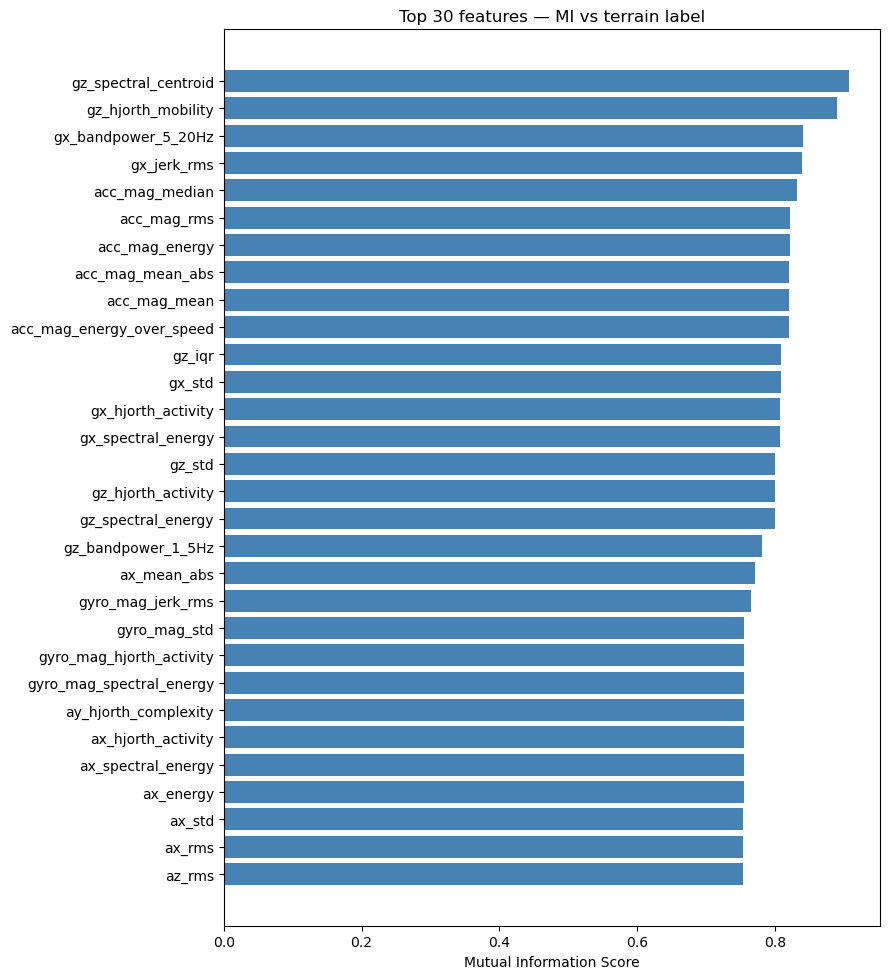


Top 30 features by mutual information (vs 'label'):
                   feature  mi_score
gyro_mag_energy_over_speed  0.755521
      gz_spectral_centroid  0.648697
        gz_hjorth_mobility  0.621334
       gx_bandpower_5_20Hz  0.605892
               gx_jerk_rms  0.597040
          acc_mag_mean_abs  0.587779
              acc_mag_mean  0.587779
            acc_mag_energy  0.583536
               acc_mag_rms  0.583349
        gz_bandpower_1_5Hz  0.582460
            acc_mag_median  0.577771
                    ay_std  0.561975
                    ay_rms  0.561975
        gx_hjorth_mobility  0.561694
               ay_mean_abs  0.561500
        ay_hjorth_activity  0.561195
                 ay_energy  0.561195
        ay_spectral_energy  0.561195
               ay_jerk_rms  0.551057
       ay_bandpower_5_20Hz  0.544993
      ay_hjorth_complexity  0.524860
      gx_spectral_centroid  0.518343
                    ay_iqr  0.517771
  gyro_mag_hjorth_mobility  0.517364
                  ay_r

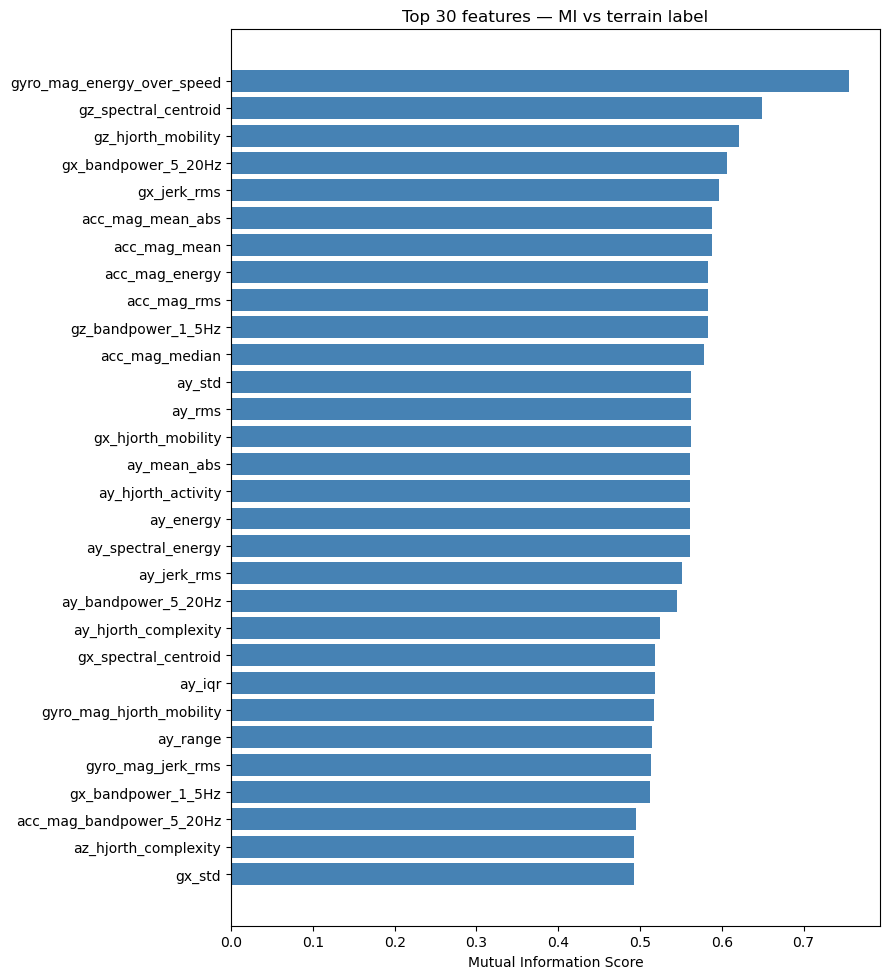


Features in top-15 for BOTH datasets (9):
  acc_mag_energy
  acc_mag_mean
  acc_mag_mean_abs
  acc_mag_median
  acc_mag_rms
  gx_bandpower_5_20Hz
  gx_jerk_rms
  gz_hjorth_mobility
  gz_spectral_centroid

Only in Dataset B top-15: ['acc_mag_energy_over_speed', 'gx_hjorth_activity', 'gx_spectral_energy', 'gx_std', 'gz_iqr', 'gz_std']
Only in Dataset A top-15: ['ay_mean_abs', 'ay_rms', 'ay_std', 'gx_hjorth_mobility', 'gyro_mag_energy_over_speed', 'gz_bandpower_1_5Hz']

Saved run-shift stability table -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/run_shift_feature_stability.csv
Top unstable label-feature pairs (highest run_cv):
           label                   feature    run_mean    run_std   run_cv
           grass       gx_bandpower_5_20Hz   79.255884  84.733215 1.069109
muddy_dirt_track       gx_bandpower_5_20Hz  172.225944 164.672064 0.956140
muddy_dirt_track        gx_spectral_energy  430.977342 310.978144 0.721565
muddy_dirt_tr

In [17]:
mi_df = None
mi_df_A = None
mi_df_B = None
top_features = feature_cols[:25]

if RUN_MI:
    print("NOTE: MI in this notebook is global EDA ranking only.")
    print("For final model comparison, use fold-local MI selection inside 07_baslines.ipynb to avoid leakage.")

    primary_df = dataset_B_tf if dataset_B_tf is not None else dataset_A_tf
    primary_name = "Dataset B" if dataset_B_tf is not None else "Dataset A"
    primary_reports_dir = PROJECT_ROOT / "reports" / "features" / ("dataset_B" if dataset_B_tf is not None else "dataset_A")

    mi_df = compute_mutual_information(
        features_df=primary_df,
        feature_cols=feature_cols,
        label_col="label",
        n_neighbors=5,
        random_state=RANDOM_STATE,
        top_n=30,
        plot=True,
        reports_dir=primary_reports_dir,
        show=True,
    )
    top_features = mi_df.head(25)["feature"].tolist()

    if dataset_B_tf is not None:
        mi_df_B = mi_df
        mi_df_A = compute_mutual_information(
            features_df=dataset_A_tf,
            feature_cols=feature_cols,
            label_col="label",
            n_neighbors=5,
            random_state=RANDOM_STATE,
            top_n=30,
            plot=True,
            reports_dir=PROJECT_ROOT / "reports" / "features" / "dataset_A",
            show=True,
        )
    else:
        mi_df_A = mi_df

    if mi_df_A is not None and mi_df_B is not None:
        top_A = set(mi_df_A.head(15)["feature"])
        top_B = set(mi_df_B.head(15)["feature"])
        print(f"\nFeatures in top-15 for BOTH datasets ({len(top_A & top_B)}):")
        for f in sorted(top_A & top_B):
            print(f"  {f}")
        print(f"\nOnly in Dataset B top-15: {sorted(top_B - top_A)}")
        print(f"Only in Dataset A top-15: {sorted(top_A - top_B)}")
    else:
        print(f"Comparison MI skipped because only {primary_name} is available.")

    # Run-shift feature stability table (high CV across runs within a label = unstable feature).
    top_for_stability = [f for f in top_features[:20] if f in dataset_A_tf.columns]
    stability_rows = []
    eps = 1e-9
    for label_name in sorted(dataset_A_tf["label"].astype(str).unique().tolist()):
        label_df = dataset_A_tf[dataset_A_tf["label"].astype(str) == label_name]
        run_means = label_df.groupby("run_id")[top_for_stability].mean(numeric_only=True)
        if run_means.empty:
            continue
        for feat in top_for_stability:
            mean_val = float(run_means[feat].mean())
            std_val = float(run_means[feat].std(ddof=0))
            cv_val = float(std_val / (abs(mean_val) + eps))
            stability_rows.append(
                {
                    "label": label_name,
                    "feature": feat,
                    "run_mean": mean_val,
                    "run_std": std_val,
                    "run_cv": cv_val,
                }
            )

    stability_df = pd.DataFrame(stability_rows).sort_values("run_cv", ascending=False).reset_index(drop=True)
    stability_out = out_dir / "run_shift_feature_stability.csv"
    stability_df.to_csv(stability_out, index=False)
    print(f"\nSaved run-shift stability table -> {stability_out}")
    print("Top unstable label-feature pairs (highest run_cv):")
    print(stability_df.head(20).to_string(index=False))
else:
    print("RUN_MI=False -> using fallback top_features = first 25 feature columns.")

## Cell 8 — Correlation pruning (guarded by RUN_PRUNING)

Pruning removes redundant features for Dataset B and defines dataset_B_final so downstream plotting has a deterministic source regardless of pruning flag state.

In [18]:
dataset_A_pruned = None
dataset_B_pruned = None
dataset_A_final = dataset_A_tf
dataset_B_final = dataset_B_tf

SPEED_CORE_COLS = [c for c in ["odom_mean_speed", "odom_speed_std", "odom_distance"] if c in dataset_A_tf.columns]

def prune_with_speed_exclusion(df_in: pd.DataFrame, dataset_name: str) -> tuple[pd.DataFrame, list[str], list[str]]:
    all_feats = get_feature_columns(df_in, id_cols=ID_COLS)
    imu_feats = [c for c in all_feats if c not in SPEED_CORE_COLS]

    pruned_imu_df, dropped_imu = drop_high_correlation_features(
        df_in,
        feature_cols=imu_feats,
        threshold=CORR_THRESHOLD,
        id_cols=ID_COLS,
    )

    speed_dropped: list[str] = []
    if len(SPEED_CORE_COLS) >= 2:
        _, speed_dropped = drop_high_correlation_features(
            df_in,
            feature_cols=SPEED_CORE_COLS,
            threshold=CORR_THRESHOLD,
            id_cols=ID_COLS,
        )

    # Keep speed columns untouched for interpretability diagnostics.
    out = pruned_imu_df.copy()
    for c in SPEED_CORE_COLS:
        if c in df_in.columns and c not in out.columns:
            out[c] = df_in[c].values

    out_cols = ID_COLS + [c for c in out.columns if c not in ID_COLS]
    out = out[out_cols]

    print(f"\n{dataset_name}: speed columns excluded from aggressive pruning: {SPEED_CORE_COLS}")
    if speed_dropped:
        print(f"{dataset_name}: speed-only redundancy check suggests drops: {speed_dropped} (kept for diagnostics)")

    return out, dropped_imu, speed_dropped

if RUN_PRUNING:
    dataset_A_pruned, dropped_cols_A, speed_drop_A = prune_with_speed_exclusion(dataset_A_tf, "Dataset A")
    remaining_cols_A = get_feature_columns(dataset_A_pruned, id_cols=ID_COLS)
    print(f"\nDataset A - Before pruning : {len(feature_cols)} features")
    print(f"Dataset A - After pruning  : {len(remaining_cols_A)} features")
    print(f"Dataset A - Dropped (IMU)  : {len(dropped_cols_A)} features")

    path_A_pruned = out_dir / "dataset_A_pruned.csv"
    dataset_A_pruned.to_csv(path_A_pruned, index=False)
    dataset_A_final = dataset_A_pruned
    print(f"Saved pruned Dataset A -> {path_A_pruned} {dataset_A_pruned.shape}")

    if dataset_B_tf is not None:
        dataset_B_pruned, dropped_cols_B, speed_drop_B = prune_with_speed_exclusion(dataset_B_tf, "Dataset B")
        remaining_cols_B = get_feature_columns(dataset_B_pruned, id_cols=ID_COLS)
        print(f"\nDataset B - Before pruning : {len(feature_cols)} features")
        print(f"Dataset B - After pruning  : {len(remaining_cols_B)} features")
        print(f"Dataset B - Dropped (IMU)  : {len(dropped_cols_B)} features")

        path_B_pruned = out_dir / "dataset_B_pruned.csv"
        dataset_B_pruned.to_csv(path_B_pruned, index=False)
        dataset_B_final = dataset_B_pruned
        print(f"Saved pruned Dataset B -> {path_B_pruned} {dataset_B_pruned.shape}")
    else:
        print("RUN_PRUNING=True but Dataset B is unavailable -> Dataset B pruning skipped.")
else:
    print("RUN_PRUNING=False -> pruning skipped.")


[Correlation pruning] threshold=0.95
  Dropped 66 features:
    acc_mag_bandpower_5_20Hz
    acc_mag_hjorth_activity
    acc_mag_hjorth_mobility
    acc_mag_iqr
    acc_mag_jerk_rms
    acc_mag_mean
    acc_mag_mean_abs
    acc_mag_median
    acc_mag_range
    acc_mag_rms
    acc_mag_std
    ax_bandpower_5_20Hz
    ax_hjorth_activity
    ax_hjorth_mobility
    ax_max
    ax_mean_abs
    ax_rms
    ax_spectral_energy
    ax_std
    ay_bandpower_5_20Hz
    ay_hjorth_activity
    ay_hjorth_mobility
    ay_iqr
    ay_max
    ay_mean_abs
    ay_min
    ay_range
    ay_rms
    ay_spectral_energy
    ay_std
    az_bandpower_5_20Hz
    az_hjorth_activity
    az_hjorth_mobility
    az_jerk_rms
    az_max
    az_mean_abs
    az_min
    az_rms
    az_spectral_energy
    az_std
    bandpower_5_20_over_speed
    gx_hjorth_activity
    gx_hjorth_mobility
    gx_max
    gx_mean_abs
    gx_min
    gx_rms
    gx_spectral_energy
    gx_std
    gyro_mag_energy
    gyro_mag_hjorth_activity
    gyro_mag_h

## Cell 9 — Pairwise separability plots (guarded by RUN_PAIRWISE_PLOTS)

This optional diagnostic focuses on hard class pairs and then visualizes final Dataset B embedding quality with PCA/t-SNE.

/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is dep

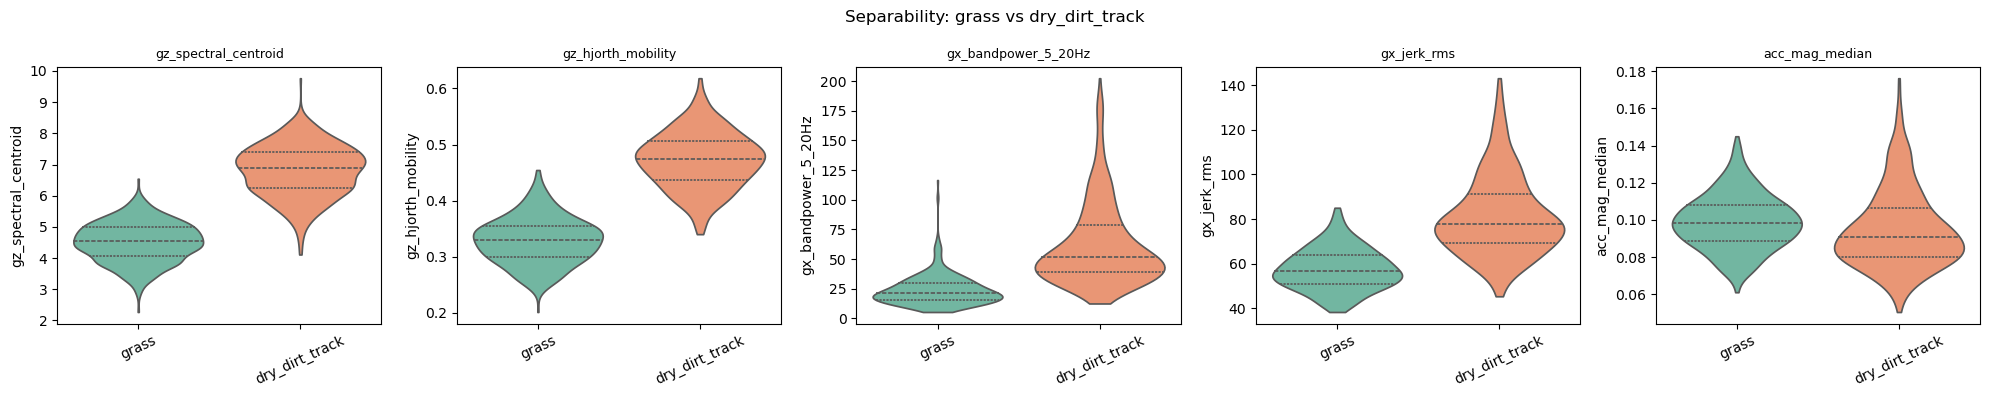

/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is dep

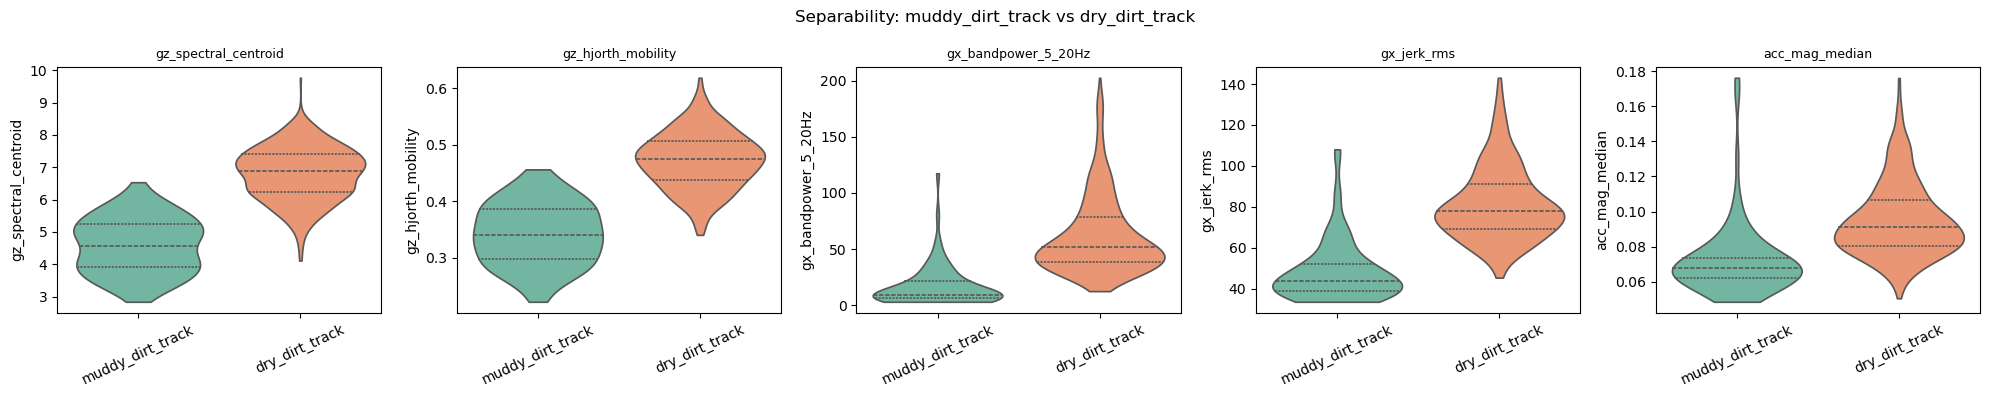

/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_66355/3801773781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is dep

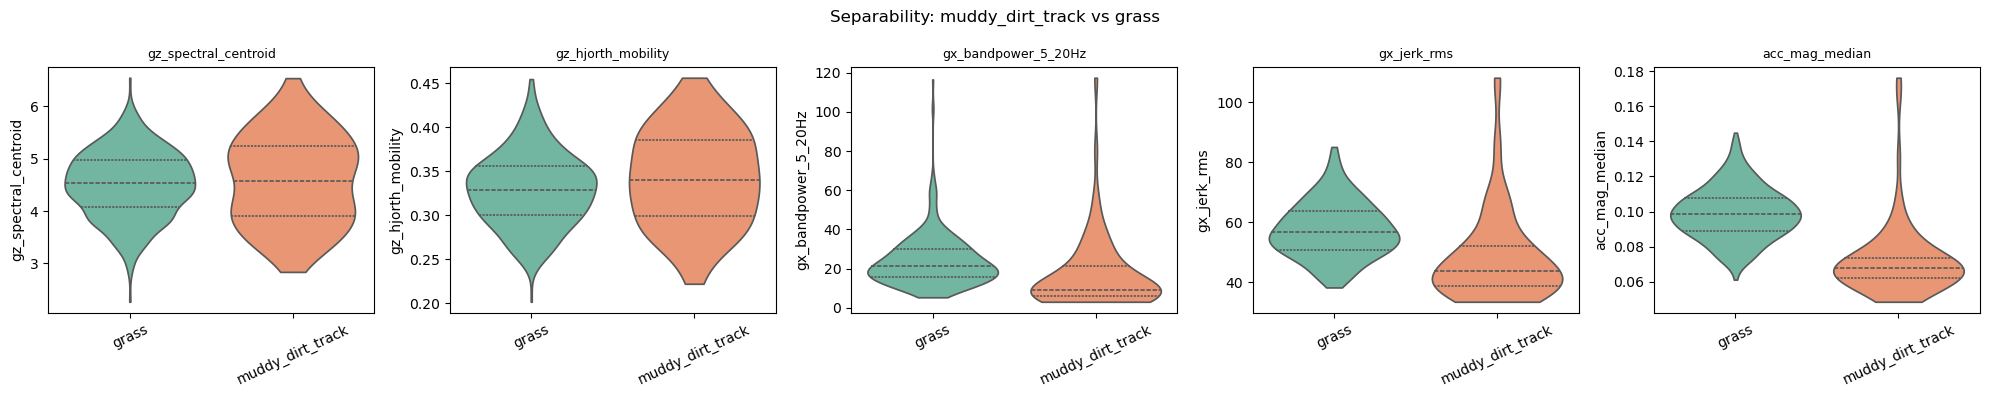

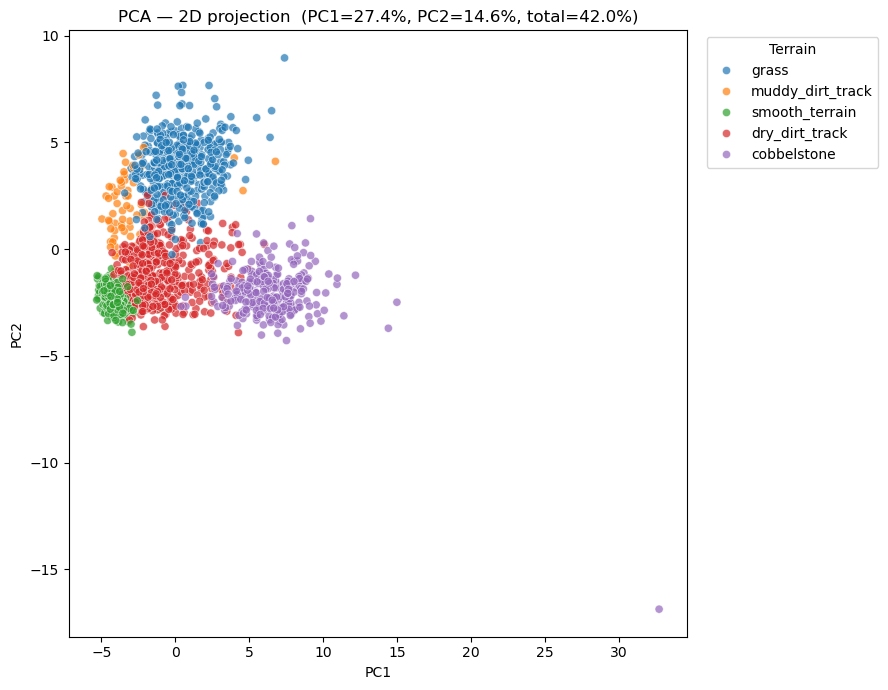

PCA explained variance: PC1=0.274, PC2=0.146, total=0.420


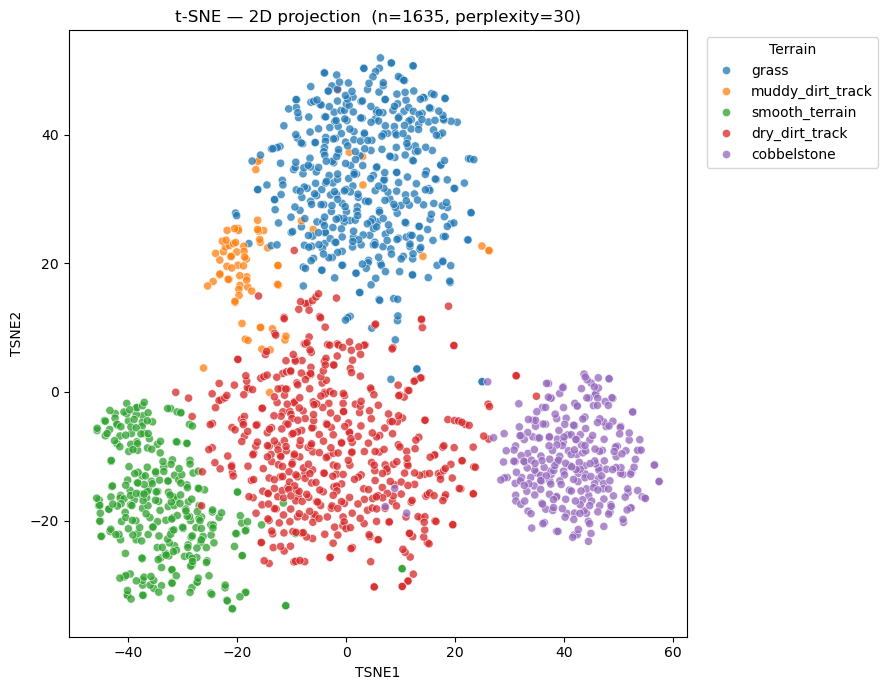

In [19]:
if RUN_PAIRWISE_PLOTS and dataset_B_final is not None:
    HARD_PAIRS = [
        ("grass", "dry_dirt_track"),
        ("muddy_dirt_track", "dry_dirt_track"),
        ("muddy_dirt_track", "grass"),
    ]

    # Thesis note: pairwise violins intentionally use unpruned dataset_B_tf for raw separability inspection,
    # while PCA/t-SNE below uses dataset_B_final (which may be pruned) to reflect the final modeling feature space.
    top5 = top_features[:5]
    for cls_a, cls_b in HARD_PAIRS:
        present_labels = set(dataset_B_tf["label"].unique()) if dataset_B_tf is not None else set()
        if cls_a not in present_labels or cls_b not in present_labels:
            print(f"Skipping pair ({cls_a}, {cls_b}) - one or both classes missing in Dataset B.")
            continue

        subset = dataset_B_tf[dataset_B_tf["label"].isin([cls_a, cls_b])]
        fig, axes = plt.subplots(1, len(top5), figsize=(4 * len(top5), 4), sharey=False)
        if len(top5) == 1:
            axes = [axes]
        fig.suptitle(f"Separability: {cls_a} vs {cls_b}", fontsize=12)

        for ax, feat in zip(axes, top5):
            if feat not in subset.columns:
                ax.set_visible(False)
                continue
            sns.violinplot(
                data=subset, x="label", y=feat, ax=ax,
                inner="quartile", cut=0, palette="Set2",
            )
            ax.set_title(feat, fontsize=9)
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=25)

        fig.tight_layout()
        plt.show()

    eda_feat_cols_B_final = get_eda_feature_columns(dataset_B_final, id_cols=ID_COLS)
    plot_pca_tsne(
        features_df=dataset_B_final,
        feature_cols=eda_feat_cols_B_final,
        label_col="label",
        reports_dir=PROJECT_ROOT / "reports" / "features" / "dataset_B",
        random_state=RANDOM_STATE,
        tsne_sample_cap=TSNE_SAMPLE_CAP,
        show=True,
    )
else:
    print("Pairwise plots skipped (RUN_PAIRWISE_PLOTS=False or Dataset B unavailable).")

## Cell 10 — Summary

This final cell reports generated artifacts, saves top MI features to JSON, and confirms readiness for model training.

In [20]:
top_features_path = out_dir / "top_mi_features.json"
with top_features_path.open("w", encoding="utf-8") as f:
    json.dump(top_features, f, indent=2)

path_B_pruned = out_dir / "dataset_B_pruned.csv"
dataset_B_saved = path_B.exists()
dataset_B_pruned_saved = path_B_pruned.exists()

print("=" * 60)
print("FEATURE EXTRACTION + ANALYSIS COMPLETE")
print("=" * 60)
print(f"  window_features.csv    : {features_df.shape[0]} windows x {features_df.shape[1]} cols")
print(f"  dataset_A_features.csv : {dataset_A_tf.shape[0]} windows x {dataset_A_tf.shape[1]} cols (log-transformed)")
if dataset_B_saved:
    print(f"  dataset_B_features.csv : {dataset_B_tf.shape[0]} windows x {dataset_B_tf.shape[1]} cols (log-transformed)")
else:
    print("  dataset_B_features.csv : SKIPPED")
if dataset_B_pruned_saved and dataset_B_pruned is not None:
    print(f"  dataset_B_pruned.csv   : {dataset_B_pruned.shape[0]} windows x {dataset_B_pruned.shape[1]} cols (pruned)")
else:
    print("  dataset_B_pruned.csv   : SKIPPED")

print("\n  Top 5 MI features (primary dataset):")
for i, feat in enumerate(top_features[:5], 1):
    print(f"    {i}. {feat}")

print(f"\n  Reports saved -> {PROJECT_ROOT / 'reports' / 'features'}")
print("  Ready for 07_models.ipynb ✓")
print(f"\nSaved top features -> {top_features_path}")

FEATURE EXTRACTION + ANALYSIS COMPLETE
  window_features.csv    : 2346 windows x 196 cols
  dataset_A_features.csv : 2346 windows x 196 cols (log-transformed)
  dataset_B_features.csv : 1635 windows x 196 cols (log-transformed)
  dataset_B_pruned.csv   : 1635 windows x 128 cols (pruned)

  Top 5 MI features (primary dataset):
    1. gz_spectral_centroid
    2. gz_hjorth_mobility
    3. gx_bandpower_5_20Hz
    4. gx_jerk_rms
    5. acc_mag_median

  Reports saved -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features
  Ready for 07_models.ipynb ✓

Saved top features -> /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/top_mi_features.json
